In [1]:
%cd ../

/home/student/pubtrends


In [8]:
!pwd

/home/student/pubtrends


In [9]:
import logging


logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')

In [10]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict


from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, ShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import zscore

from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
# from xgboost import XGBRegressor
from functools import partial

import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from tqdm import tqdm

%matplotlib inline
plt.rcParams["axes.labelsize"] = 16.
plt.rcParams["xtick.labelsize"] = 14.
plt.rcParams["ytick.labelsize"] = 14.
plt.rcParams["legend.fontsize"] = 12.
plt.rcParams["figure.figsize"] = [13., 9.]

In [174]:
df = pd.read_csv('tmp_data/total_df_eng_lda_8.csv')
df = df.set_index('idx')
df.head()

,year,c2,c5,c_all,num_of_authors,num_words_title,num_words_abs,lang,productivity,is_main_ratio,...,diversity,dominant_topic,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8
idx,,,,,,,,,,,,,,,,,,,,,
39a4e80e18b65330681472805135b2d4ca7f5068,1994.0,0,0,0,2,5,137,en,0.107143,0.333333,...,0.209274,4,0.055085,0.104188,0.068443,0.490352,0.056641,0.074947,0.075281,0.075062
39c379bf33f1adbe6e5b49938336c4743571bb34,2015.0,0,0,0,1,11,65,en,0.142857,1.000000,...,0.247922,8,0.097846,0.093786,0.088906,0.088254,0.089061,0.202697,0.092598,0.246853
39d3f3710fafb9a886044e9979d483f940a45b14,2021.0,0,0,0,7,16,391,en,1.000000,0.500000,...,0.227813,4,0.226371,0.180238,0.141029,0.276339,0.046794,0.028567,0.051429,0.049232
57e49dc22ff5e756ef29fe7b664a39a4d34b746b,2020.0,0,0,0,0,6,242,en,0.000000,0.000000,...,0.230062,6,0.236301,0.084452,0.048899,0.059312,0.069006,0.322472,0.065733,0.113826
3a9398fb520ef571ed125f35cfe92df54197bcc5,2003.0,0,0,0,6,12,82,en,0.052632,0.500000,...,0.238422,5,0.088368,0.073890,0.075126,0.097389,0.320682,0.082268,0.186181,0.076096


In [175]:
def simple_encoding(df, target_col, col):
    res = df.copy()
    range_set = set(df[col])
    buff = {}
    for el in range_set:
        tmp = df[df[col] == el]
        mean, median, mn, mx = np.mean(tmp[target_col]), np.median(tmp[target_col]), min(tmp[target_col]), max(tmp[target_col])
        buff[el] = (mean, median, mn, mx)
    mean_ls, med_ls, mn_ls, mx_ls = [], [], [], []
    for item in df[col]:
        mean_ls.append(buff[item][0])
        med_ls.append(buff[item][1])
        mn_ls.append(buff[item][2])
        mx_ls.append(buff[item][3])
    res[f'topic_mean_{target_col}'] = mean_ls
    res[f'topic_median_{target_col}'] = med_ls
    res[f'topic_min_{target_col}'] = mn_ls
    res[f'topic_max_{target_col}'] = mx_ls
    return res

In [176]:
df = df[df.lang == 'en']
df = df[df.year >= 2000]
df = simple_encoding(df, 'c_all', 'dominant_topic')
df = simple_encoding(df, 'c2', 'dominant_topic')
df = simple_encoding(df, 'c5', 'dominant_topic')
# df = df[df.dominant_topic == 8]
df_c5 = df[df['year'] < 2016]
df_c2 = df[df['year'] < 2019]
df_all = df[df['year'] < 2016]

In [177]:
X_c5 = df_c5.drop(columns=['c5', 'c_all'])
y_c5 = df_c5.c5

X_c2 = df_c2.drop(columns=['c2', 'c5', 'c_all'])
y_c2 = df_c2.c2

X_all = df_all.drop(columns=['c_all'])
y_all = df_all.c_all

In [178]:
X_all

,year,c2,c5,num_of_authors,num_words_title,num_words_abs,lang,productivity,is_main_ratio,sociality,...,topic_min_c_all,topic_max_c_all,topic_mean_c2,topic_median_c2,topic_min_c2,topic_max_c2,topic_mean_c5,topic_median_c5,topic_min_c5,topic_max_c5
idx,,,,,,,,,,,,,,,,,,,,,
39c379bf33f1adbe6e5b49938336c4743571bb34,2015.0,0,0,1,11,65,en,0.142857,1.000000,0.000000,...,0,12434,2.862816,1.0,0,1635,6.036695,1.0,0,3638
3a9398fb520ef571ed125f35cfe92df54197bcc5,2003.0,0,0,6,12,82,en,0.052632,0.500000,5.000000,...,0,7369,3.210732,1.0,0,728,6.801336,1.0,0,1420
3b55f92a9d4ad697ee81291e84e294287abca397,2009.0,0,0,2,4,118,en,0.076923,0.500000,1.000000,...,0,12769,2.056413,0.0,0,1056,4.401154,0.0,0,4170
3c292a40e43508de4f9d10d293caa2f8562c46ef,2010.0,0,0,1,5,229,en,0.150000,0.666667,4.666667,...,0,12434,2.862816,1.0,0,1635,6.036695,1.0,0,3638
0826e1b527c9cd460a3c672ce152c2f0447688e8,2011.0,0,0,5,9,77,en,0.181818,0.333333,3.500000,...,0,4664,1.527321,0.0,0,758,3.590565,0.0,0,1737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3ef744b4dfe65bf55d7250050cafe42c439a21a5,2012.0,0,0,2,5,52,en,0.200000,0.500000,1.000000,...,0,4664,1.527321,0.0,0,758,3.590565,0.0,0,1737
f60379bd9cdf41a4a98a2d8c729d997d6c28060b,2006.0,0,0,3,5,82,en,0.062500,0.500000,2.000000,...,0,12769,2.056413,0.0,0,1056,4.401154,0.0,0,4170
db42e128cd44392cc2219e0d8628858975a5cfd1,2007.0,0,0,1,13,57,en,0.066667,1.000000,0.000000,...,0,3426,3.048377,0.0,0,641,6.748875,1.0,0,1326


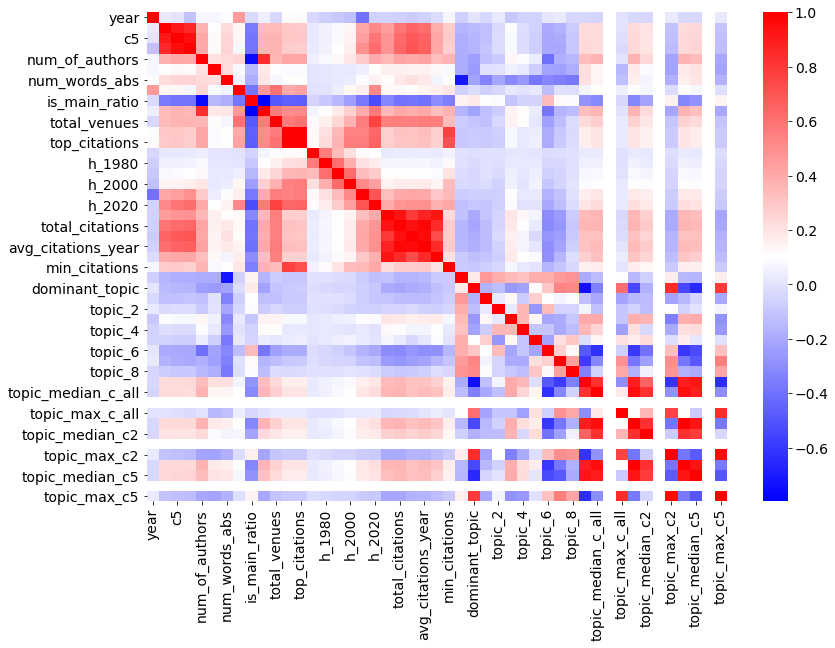

In [179]:
sns.heatmap(df_c5.corr(method='spearman'), cmap='bwr');

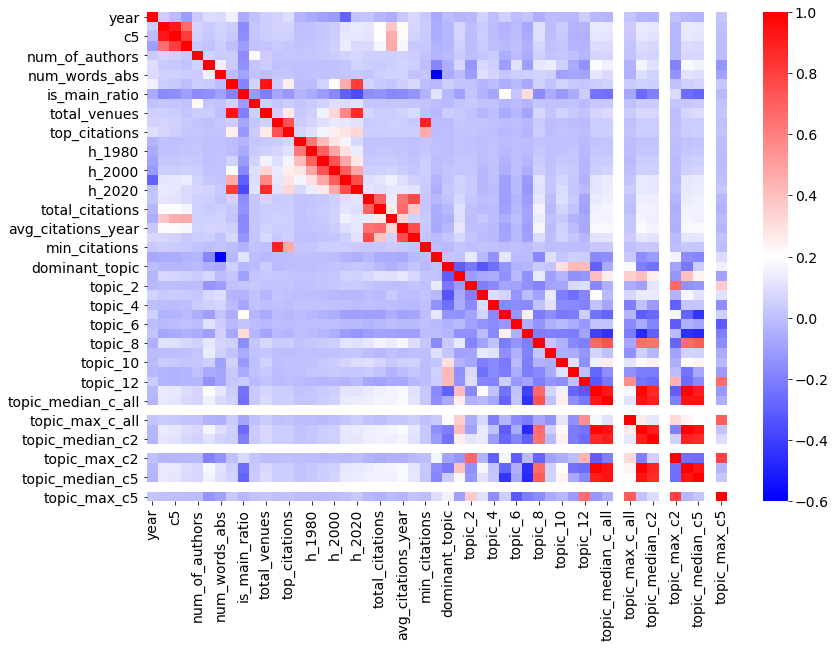

In [137]:
sns.heatmap(df_c2.corr(), cmap='bwr');

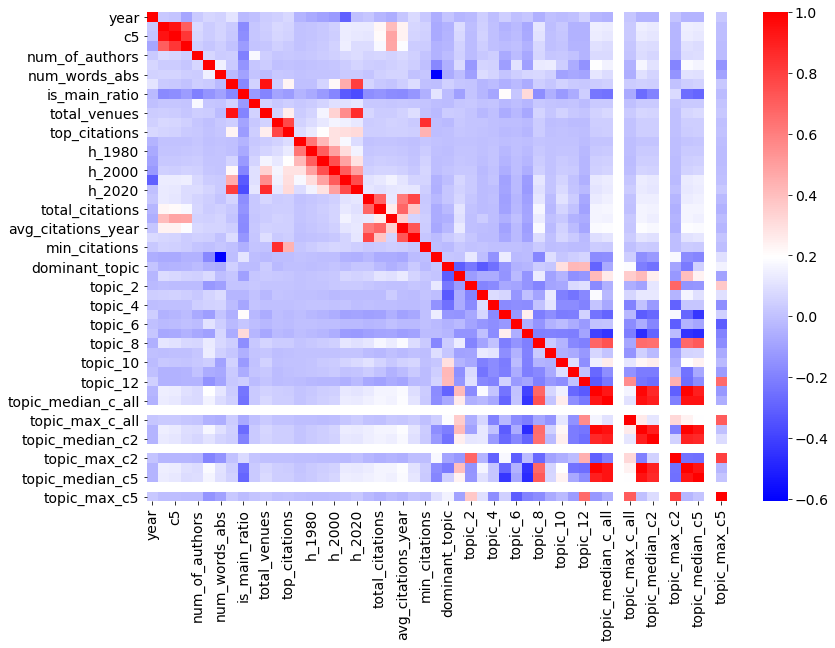

In [138]:
sns.heatmap(df_all.corr(), cmap='bwr');

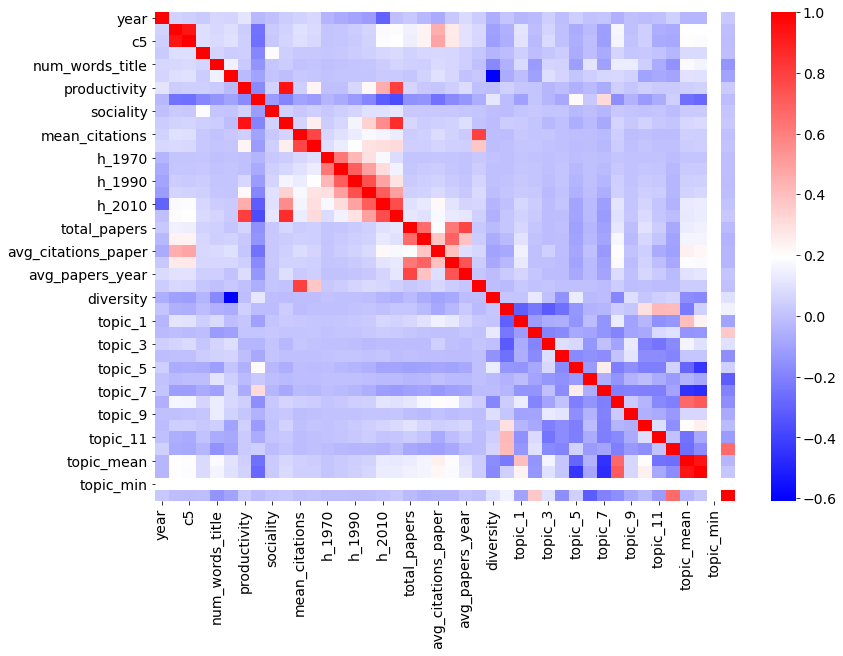

In [139]:
sns.heatmap(X_train_all.corr(), cmap='bwr');

### Create dummies from lang

In [180]:
def get_dummies_lang(X):
    res = X.copy()
    counts = pd.value_counts(res.lang)
    s = set(counts[counts > 15000].index)
    X['lang'] = X.lang.apply(lambda x: x if x in s else 'None')
    lang_dummies = pd.get_dummies(X.lang)
    res = X.merge(lang_dummies, left_index=True, right_index=True)
    res = res.drop(columns=['lang'])
    return res

In [181]:
def get_train_test_split(X, y, outliers=True):
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=73, test_size=0.2)
    if outliers:
        ind = abs(zscore(y_train)) < 3

        X_train = X_train[ind]
        y_train = y_train[ind]
    return X_train, X_test, y_train, y_test

In [182]:
# X_c5 = get_dummies_lang(X_c5)
X_train_c5, X_test_c5, y_train_c5, y_test_c5 = get_train_test_split(X_c5, y_c5)

In [183]:
# X_c2 = get_dummies_lang(X_c2)
X_train_c2, X_test_c2, y_train_c2, y_test_c2 = get_train_test_split(X_c2, y_c2)

In [184]:
# X_all = get_dummies_lang(X_all)
X_train_all, X_test_all, y_train_all, y_test_all = get_train_test_split(X_all, y_all)

In [185]:
def check_test(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    return r2_score(y_test, model.predict(X_test))

def cross_val_model(model, X_train, y_train, scoring, cv):
    ls = cross_val_score(model, X_train, y_train, scoring=scoring, cv=cv)
    print(f"{scoring} = {np.mean(ls)} +- {np.std(ls)}")

In [186]:
ridge_pipe = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

rf_pipe =  Pipeline([
    ('imputer', SimpleImputer()),
    ('rf', RandomForestRegressor(random_state=0))
])

grad_pipe =  Pipeline([
    ('imputer', SimpleImputer()),
    ('grad', GradientBoostingRegressor(random_state=0))
])


catb_model = CatBoostRegressor(verbose=0)

In [187]:
X_all

,year,c2,c5,num_of_authors,num_words_title,num_words_abs,lang,productivity,is_main_ratio,sociality,...,topic_min_c_all,topic_max_c_all,topic_mean_c2,topic_median_c2,topic_min_c2,topic_max_c2,topic_mean_c5,topic_median_c5,topic_min_c5,topic_max_c5
idx,,,,,,,,,,,,,,,,,,,,,
39c379bf33f1adbe6e5b49938336c4743571bb34,2015.0,0,0,1,11,65,en,0.142857,1.000000,0.000000,...,0,12434,2.862816,1.0,0,1635,6.036695,1.0,0,3638
3a9398fb520ef571ed125f35cfe92df54197bcc5,2003.0,0,0,6,12,82,en,0.052632,0.500000,5.000000,...,0,7369,3.210732,1.0,0,728,6.801336,1.0,0,1420
3b55f92a9d4ad697ee81291e84e294287abca397,2009.0,0,0,2,4,118,en,0.076923,0.500000,1.000000,...,0,12769,2.056413,0.0,0,1056,4.401154,0.0,0,4170
3c292a40e43508de4f9d10d293caa2f8562c46ef,2010.0,0,0,1,5,229,en,0.150000,0.666667,4.666667,...,0,12434,2.862816,1.0,0,1635,6.036695,1.0,0,3638
0826e1b527c9cd460a3c672ce152c2f0447688e8,2011.0,0,0,5,9,77,en,0.181818,0.333333,3.500000,...,0,4664,1.527321,0.0,0,758,3.590565,0.0,0,1737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3ef744b4dfe65bf55d7250050cafe42c439a21a5,2012.0,0,0,2,5,52,en,0.200000,0.500000,1.000000,...,0,4664,1.527321,0.0,0,758,3.590565,0.0,0,1737
f60379bd9cdf41a4a98a2d8c729d997d6c28060b,2006.0,0,0,3,5,82,en,0.062500,0.500000,2.000000,...,0,12769,2.056413,0.0,0,1056,4.401154,0.0,0,4170
db42e128cd44392cc2219e0d8628858975a5cfd1,2007.0,0,0,1,13,57,en,0.066667,1.000000,0.000000,...,0,3426,3.048377,0.0,0,641,6.748875,1.0,0,1326


In [188]:
experiments = {
    'c_all_from_c2_c5_mean_top': {
        'exclude_features': ['c_all'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2016,
        'target': 'c_all',
        'test_size': 0.25
    },
    'c_all_without_c2_c5': {
        'exclude_features': ['c2', 'c5', 'c_all'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2016,
        'target': 'c_all',
        'test_size': 0.25
    },
    
    'c_all_without_mean_top': {
        'exclude_features': ['c_all', 'mean_citations', 'top_citations', 'min_citations'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2016,
        'target': 'c_all',
        'test_size': 0.25
    },
    
    'c_5_from_c2_mean_top': {
        'exclude_features': ['c_all', 'c5'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2016,
        'target': 'c5',
        'test_size': 0.25
    },
    'c_5_without_c2': {
        'exclude_features': ['c2', 'c_all', 'c5'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2016,
        'target': 'c5',
        'test_size': 0.25
    },
    'c_5_without_c2_mean_top': {
        'exclude_features': ['c2', 'c5', 'c_all', 'mean_citations', 'top_citations', 'min_citations'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2016,
        'target': 'c5',
        'test_size': 0.25
    },
    
    'c_2_from_mean_top': {
        'exclude_features': ['c2', 'c_all', 'c5'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2019,
        'target': 'c2',
        'test_size': 0.25
    },
    'c_2_without_mean_top': {
        'exclude_features': ['c2', 'c5', 'c_all', 'mean_citations', 'top_citations', 'min_citations'],
        'folds': 10,
        'metrics': ['rmse', 'r2'],
        'random_state': 42,
        'year': 2019,
        'target': 'c2',
        'test_size': 0.25
    },
}


metrics = {
    'rmse': partial(mean_squared_error, squared=False),
    'r2': r2_score,
    'mape': mean_absolute_percentage_error,
}
ss = ShuffleSplit(n_splits=5, test_size=0.25, random_state=0)

In [189]:
def validate_model(model, df, exp_info, metrics):
    logging.info(f'Started experimnet')
    shufler = ShuffleSplit(n_splits=exp_info['folds'],
                           test_size=exp_info['test_size'],
                           random_state=exp_info['random_state'])
    
    tmp = df[df['year'] < exp_info['year']]
    tmp = get_dummies_lang(tmp)
    X = tmp.drop(columns=exp_info['exclude_features'])
    y = tmp[f'{exp_info["target"]}']
    
    results = defaultdict(list)
    for i, (train_idx, test_idx) in enumerate(shufler.split(X)):
        logging.info(f'Train for split {i + 1}')
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        logging.info('Metrics calculation')
        for metr in exp_info['metrics']:
            score = metrics[metr](y_test, preds)
            results[metr].append(score)
        results['importances'].append(list(zip(map(float, model.get_feature_importance()), X_train.columns)))
    return dict(results)

In [190]:
def drop_outliers(data, target):
    ind = abs(zscore(target)) < 3
    
    X = data[ind]
    y = target[ind]
    return X, y, len(data) - len(X)

In [336]:
themd_d = {
    1: 'biology',
    4: 'cardiology',
    2: 'pediatrics',
    3: 'biochemic',
    5: 'chemistry',
    6: 'eco, social',
    7: 'eng and cs',
    8: 'physics',
    0: 'w/o lda'
}

df['d_top'] = df.dominant_topic.apply(lambda x: themd_d[x])

In [337]:
df

,year,c2,c5,c_all,num_of_authors,num_words_title,num_words_abs,lang,productivity,is_main_ratio,...,topic_max_c_all,topic_mean_c2,topic_median_c2,topic_min_c2,topic_max_c2,topic_mean_c5,topic_median_c5,topic_min_c5,topic_max_c5,d_top
idx,,,,,,,,,,,,,,,,,,,,,
39c379bf33f1adbe6e5b49938336c4743571bb34,2015.0,0,0,0,1,11,65,en,0.142857,1.000000,...,12434,2.862816,1.0,0,1635,6.036695,1.0,0,3638,physics
39d3f3710fafb9a886044e9979d483f940a45b14,2021.0,0,0,0,7,16,391,en,1.000000,0.500000,...,3426,3.048377,0.0,0,641,6.748875,1.0,0,1326,cardiology
57e49dc22ff5e756ef29fe7b664a39a4d34b746b,2020.0,0,0,0,0,6,242,en,0.000000,0.000000,...,4664,1.527321,0.0,0,758,3.590565,0.0,0,1737,"eco, social"
3a9398fb520ef571ed125f35cfe92df54197bcc5,2003.0,0,0,0,6,12,82,en,0.052632,0.500000,...,7369,3.210732,1.0,0,728,6.801336,1.0,0,1420,chemistry
01396cb1b738639c446f99d7d47284c7a662fd16,2020.0,0,0,0,8,14,335,en,0.500000,0.500000,...,2872,2.512631,0.0,0,263,5.755055,1.0,0,504,biology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f60379bd9cdf41a4a98a2d8c729d997d6c28060b,2006.0,0,0,1,3,5,82,en,0.062500,0.500000,...,12769,2.056413,0.0,0,1056,4.401154,0.0,0,4170,eng and cs
db42e128cd44392cc2219e0d8628858975a5cfd1,2007.0,0,0,1,1,13,57,en,0.066667,1.000000,...,3426,3.048377,0.0,0,641,6.748875,1.0,0,1326,cardiology
7ce5dbacfbbb1ed67ce5b55ceca4f472b7c06aaa,2018.0,8,8,8,3,9,121,en,0.208333,0.166667,...,12769,2.056413,0.0,0,1056,4.401154,0.0,0,4170,eng and cs


In [358]:
df.columns

Index(['year', 'c2', 'c5', 'c_all', 'num_of_authors', 'num_words_title',
       'num_words_abs', 'lang', 'productivity', 'is_main_ratio', 'sociality',
       'total_venues', 'mean_citations', 'top_citations', 'h_1970', 'h_1980',
       'h_1990', 'h_2000', 'h_2010', 'h_2020', 'total_papers',
       'total_citations', 'avg_citations_paper', 'avg_citations_year',
       'avg_papers_year', 'min_citations', 'diversity', 'dominant_topic',
       'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6',
       'topic_7', 'topic_8', 'topic_mean_c_all', 'topic_median_c_all',
       'topic_min_c_all', 'topic_max_c_all', 'topic_mean_c2',
       'topic_median_c2', 'topic_min_c2', 'topic_max_c2', 'topic_mean_c5',
       'topic_median_c5', 'topic_min_c5', 'topic_max_c5', 'd_top',
       'Year of publication', 'Impact factor of journal'],
      dtype='object')

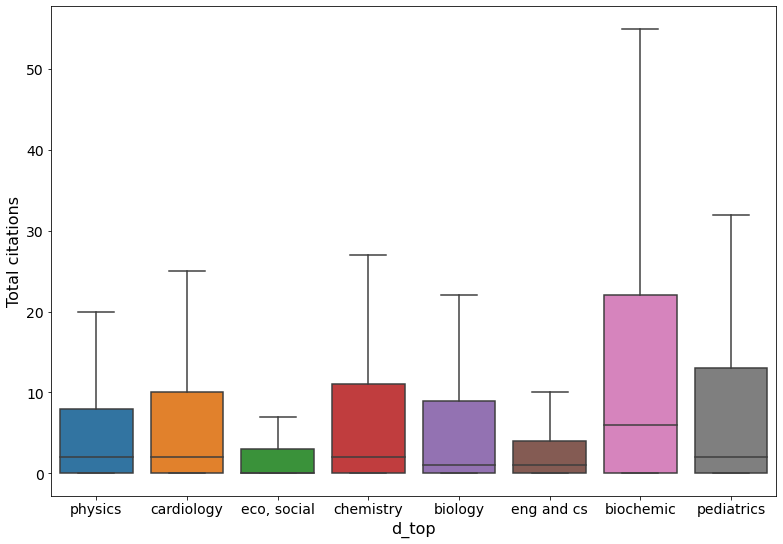

In [360]:
for col in df.columns[:-1]:
#     if col != 'dominant_topic' and col != 'lang':
    if col == 'Total citations':
        plt.figure()
        if 'c_all' in df.columns:
            df['Total citations'] = df['c_all']
        if 'year' in df.columns:
            df['Year of publication'] = df.year
        if 'c2' in df.columns:
            df['Two year citations'] = df.c2
        if 'avg_citations_paper' in df.columns:
            df['Impact factor of journal'] = df['avg_citations_paper']
        ax = sns.boxplot(x='d_top', y=col, data=df, showfliers = False)

In [192]:
%%time
results = {}
for i, item in enumerate(experiments):
    logging.info(f'Started experiment num {i + 1} with name {item}')
    results[item] = validate_model(catb_model, df, experiments[item], metrics)
    logging.info(f'R2 metric or experiment {item}: {results[item]["r2"]}')

2021-08-25 13:59:56,731 INFO: Started experiment num 1 with name c_all_from_c2_c5_mean_top
2021-08-25 13:59:56,732 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
2021-08-25 13:59:57,008 INFO: Train for split 1
Custom logger is already specified. Specify more than one logger at same time is not thread safe.2021-08-25 14:00:14,049 INFO: Metrics calculation
2021-08-25 14:00:14,079 INFO: Train for split 2
2021-08-25 14:00:31,247 INFO: Metrics calculation
2021-08-25 14:00:31,277 INFO: Train for split 3
2021-08-25 14:00:48,304 INFO: Metrics calculation
2021-08-25 14:00:48,335 INFO: Train for split 4
2021-08-25 14:01:05,406 INFO: Me

2021-08-25 14:12:47,929 INFO: Metrics calculation
2021-08-25 14:12:47,961 INFO: Train for split 6
2021-08-25 14:13:05,117 INFO: Metrics calculation
2021-08-25 14:13:05,149 INFO: Train for split 7
2021-08-25 14:13:22,344 INFO: Metrics calculation
2021-08-25 14:13:22,375 INFO: Train for split 8
2021-08-25 14:13:39,630 INFO: Metrics calculation
2021-08-25 14:13:39,660 INFO: Train for split 9
2021-08-25 14:13:56,782 INFO: Metrics calculation
2021-08-25 14:13:56,812 INFO: Train for split 10
2021-08-25 14:14:13,882 INFO: Metrics calculation
2021-08-25 14:14:13,918 INFO: R2 metric or experiment c_5_without_c2: [0.28045318403915054, 0.21875054412254635, 0.23362748793672805, 0.21217389420223043, 0.1992959069297493, 0.2557540742051875, 0.2832443401373076, 0.2285491470855896, 0.287705062642149, 0.2503163038606625]
2021-08-25 14:14:13,918 INFO: Started experiment num 6 with name c_5_without_c2_mean_top
2021-08-25 14:14:13,919 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/p

CPU times: user 2h 57min 52s, sys: 3min 32s, total: 3h 1min 24s
Wall time: 24min 3s


In [193]:
topic_3_df = df[df.dominant_topic == 3]

In [194]:
%%time
results_top3 = {}
for i, item in enumerate(experiments):
    logging.info(f'Started experiment num {i + 1} with name {item}')
    results_top3[item] = validate_model(catb_model, topic_3_df, experiments[item], metrics)
    logging.info(f'R2 metric or experiment {item}: {results_top3[item]["r2"]}')

2021-08-25 14:24:00,475 INFO: Started experiment num 1 with name c_all_from_c2_c5_mean_top
2021-08-25 14:24:00,476 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
2021-08-25 14:24:00,513 INFO: Train for split 1
2021-08-25 14:24:04,149 INFO: Metrics calculation
2021-08-25 14:24:04,157 INFO: Train for split 2
2021-08-25 14:24:07,774 INFO: Metrics calculation
2021-08-25 14:24:07,783 INFO: Train for split 3
2021-08-25 14:24:11,405 INFO: Metrics calculation
2021-08-25 14:24:11,414 INFO: Train for split 4
2021-08-25 14:24:15,088 INFO: Metrics calculation
2021-08-25 14:24:15,097 INFO: Train for split 5
2021-08-25 14:24:18,701 INFO: M

2021-08-25 14:26:42,967 INFO: Metrics calculation
2021-08-25 14:26:42,976 INFO: Train for split 7
2021-08-25 14:26:46,438 INFO: Metrics calculation
2021-08-25 14:26:46,447 INFO: Train for split 8
2021-08-25 14:26:49,929 INFO: Metrics calculation
2021-08-25 14:26:49,938 INFO: Train for split 9
2021-08-25 14:26:53,417 INFO: Metrics calculation
2021-08-25 14:26:53,425 INFO: Train for split 10
2021-08-25 14:26:56,867 INFO: Metrics calculation
2021-08-25 14:26:56,876 INFO: R2 metric or experiment c_5_without_c2: [0.35542643933221685, 0.3074177620202103, 0.3643581060491502, 0.3409378337778718, 0.3375772748547661, 0.31830854651658, 0.28857292813734237, 0.3092332326711472, 0.32865361648190927, 0.320971239966513]
2021-08-25 14:26:56,877 INFO: Started experiment num 6 with name c_5_without_c2_mean_top
2021-08-25 14:26:56,877 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set 

CPU times: user 33min, sys: 1min 59s, total: 34min 59s
Wall time: 4min 44s


In [195]:
topic_6_df = df[df.dominant_topic == 6]

In [196]:
%%time
results_top6 = {}
for i, item in enumerate(experiments):
    logging.info(f'Started experiment num {i + 1} with name {item}')
    results_top6[item] = validate_model(catb_model, topic_6_df, experiments[item], metrics)
    logging.info(f'R2 metric or experiment {item}: {results_top6[item]["r2"]}')

2021-08-25 14:28:45,412 INFO: Started experiment num 1 with name c_all_from_c2_c5_mean_top
2021-08-25 14:28:45,413 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
2021-08-25 14:28:45,467 INFO: Train for split 1
2021-08-25 14:28:49,957 INFO: Metrics calculation
2021-08-25 14:28:49,968 INFO: Train for split 2
2021-08-25 14:28:54,447 INFO: Metrics calculation
2021-08-25 14:28:54,457 INFO: Train for split 3
2021-08-25 14:28:58,939 INFO: Metrics calculation
2021-08-25 14:28:58,948 INFO: Train for split 4
2021-08-25 14:29:03,456 INFO: Metrics calculation
2021-08-25 14:29:03,467 INFO: Train for split 5
2021-08-25 14:29:07,955 INFO: M

2021-08-25 14:32:07,300 INFO: Metrics calculation
2021-08-25 14:32:07,310 INFO: Train for split 7
2021-08-25 14:32:11,707 INFO: Metrics calculation
2021-08-25 14:32:11,717 INFO: Train for split 8
2021-08-25 14:32:16,136 INFO: Metrics calculation
2021-08-25 14:32:16,146 INFO: Train for split 9
2021-08-25 14:32:20,545 INFO: Metrics calculation
2021-08-25 14:32:20,555 INFO: Train for split 10
2021-08-25 14:32:24,896 INFO: Metrics calculation
2021-08-25 14:32:24,908 INFO: R2 metric or experiment c_5_without_c2: [0.0661874055315056, 0.16149124517145763, 0.10897426036976166, 0.05828537787212873, 0.11333028482733831, 0.15798363388879044, -0.4471669513212466, 0.08377246661284299, 0.075478794795935, 0.10639847875135033]
2021-08-25 14:32:24,908 INFO: Started experiment num 6 with name c_5_without_c2_mean_top
2021-08-25 14:32:24,909 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to 

CPU times: user 43min 39s, sys: 2min 11s, total: 45min 51s
Wall time: 6min 4s


In [238]:
def func(target_d, exp_name):
    tmp = defaultdict(list)
    for arr in target_d[exp_name]['importances']:
        for el, val in arr:
            tmp[val].append(el)
    tmp = dict(tmp)
    return tmp

In [271]:
data_for_box = {}
for j in tqdm(range(8)):
    logging.info(f'Started experiment topic {j + 1}')
    tar_df = df[df.dominant_topic == j + 1]
    res = {}
    for i, item in enumerate(experiments):
        logging.info(f'Started experiment num {i + 1} with name {item}')
        res[item] = validate_model(catb_model, tar_df, experiments[item], metrics)
        logging.info(f'R2 metric or experiment {item}: {res[item]["r2"]}')
    data_for_box[j + 1] = res

  0%|          | 0/8 [00:00<?, ?it/s]2021-08-25 17:16:25,042 INFO: Started experiment topic 1
2021-08-25 17:16:25,057 INFO: Started experiment num 1 with name c_all_from_c2_c5_mean_top
2021-08-25 17:16:25,058 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
2021-08-25 17:16:25,088 INFO: Train for split 1
2021-08-25 17:16:28,376 INFO: Metrics calculation
2021-08-25 17:16:28,384 INFO: Train for split 2
2021-08-25 17:16:31,709 INFO: Metrics calculation
2021-08-25 17:16:31,717 INFO: Train for split 3
2021-08-25 17:16:35,060 INFO: Metrics calculation
2021-08-25 17:16:35,091 INFO: Train for split 4
2021-08-25 17:16:38,475 INFO: Metri

2021-08-25 17:18:52,855 INFO: Metrics calculation
2021-08-25 17:18:52,863 INFO: Train for split 6
2021-08-25 17:18:56,152 INFO: Metrics calculation
2021-08-25 17:18:56,183 INFO: Train for split 7
2021-08-25 17:18:59,462 INFO: Metrics calculation
2021-08-25 17:18:59,470 INFO: Train for split 8
2021-08-25 17:19:02,705 INFO: Metrics calculation
2021-08-25 17:19:02,713 INFO: Train for split 9
2021-08-25 17:19:05,932 INFO: Metrics calculation
2021-08-25 17:19:05,940 INFO: Train for split 10
2021-08-25 17:19:09,173 INFO: Metrics calculation
2021-08-25 17:19:09,182 INFO: R2 metric or experiment c_5_without_c2: [0.33997780790346643, 0.30151838581963486, 0.31283239538901697, 0.3561370122519619, 0.3564391204515194, 0.29092070196100794, 0.32629862654230335, 0.3570794244592681, 0.3035329607573618, 0.3581218087593121]
2021-08-25 17:19:09,182 INFO: Started experiment num 6 with name c_5_without_c2_mean_top
2021-08-25 17:19:09,183 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib

/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
2021-08-25 17:21:20,025 INFO: Train for split 1
2021-08-25 17:21:22,935 INFO: Metrics calculation
2021-08-25 17:21:22,964 INFO: Train for split 2
2021-08-25 17:21:25,833 INFO: Metrics calculation
2021-08-25 17:21:25,840 INFO: Train for split 3
2021-08-25 17:21:28,706 INFO: Metrics calculation
2021-08-25 17:21:28,735 INFO: Train for split 4
2021-08-25 17:21:31,757 INFO: Metrics calculation
2021-08-25 17:21:31,787 INFO: Train for split 5
2021-08-25 17:21:34,622 INFO: Metrics calculation
2021-08-25 17:21:34,630 INFO: Train for split 6
2021-08-25 17:21:37,444 INFO: Metrics calculation
2021-08-25 17:21:37,452

2021-08-25 17:23:33,742 INFO: Train for split 8
2021-08-25 17:23:36,470 INFO: Metrics calculation
2021-08-25 17:23:36,477 INFO: Train for split 9
2021-08-25 17:23:39,159 INFO: Metrics calculation
2021-08-25 17:23:39,166 INFO: Train for split 10
2021-08-25 17:23:41,889 INFO: Metrics calculation
2021-08-25 17:23:41,917 INFO: R2 metric or experiment c_5_without_c2_mean_top: [0.06187146912858543, 0.08864282108137223, 0.09543787584296393, 0.08393818988614965, 0.12987184815050223, 0.045798431375678295, 0.1298070490196973, 0.1165010638110654, 0.11758114862172597, 0.16093801013157605]
2021-08-25 17:23:41,918 INFO: Started experiment num 7 with name c_2_from_mean_top
2021-08-25 17:23:41,920 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

2021-08-25 17:25:58,143 INFO: Metrics calculation
2021-08-25 17:25:58,151 INFO: Train for split 2
2021-08-25 17:26:01,514 INFO: Metrics calculation
2021-08-25 17:26:01,523 INFO: Train for split 3
2021-08-25 17:26:04,925 INFO: Metrics calculation
2021-08-25 17:26:04,937 INFO: Train for split 4
2021-08-25 17:26:08,374 INFO: Metrics calculation
2021-08-25 17:26:08,406 INFO: Train for split 5
2021-08-25 17:26:11,806 INFO: Metrics calculation
2021-08-25 17:26:11,815 INFO: Train for split 6
2021-08-25 17:26:15,201 INFO: Metrics calculation
2021-08-25 17:26:15,210 INFO: Train for split 7
2021-08-25 17:26:18,584 INFO: Metrics calculation
2021-08-25 17:26:18,593 INFO: Train for split 8
2021-08-25 17:26:21,969 INFO: Metrics calculation
2021-08-25 17:26:21,978 INFO: Train for split 9
2021-08-25 17:26:25,365 INFO: Metrics calculation
2021-08-25 17:26:25,374 INFO: Train for split 10
2021-08-25 17:26:28,718 INFO: Metrics calculation
2021-08-25 17:26:28,727 INFO: R2 metric or experiment c_all_without

...

2021-08-25 17:40:35,243 INFO: Metrics calculation
2021-08-25 17:40:35,253 INFO: Train for split 2
2021-08-25 17:40:39,709 INFO: Metrics calculation
2021-08-25 17:40:39,718 INFO: Train for split 3
2021-08-25 17:40:44,187 INFO: Metrics calculation
2021-08-25 17:40:44,198 INFO: Train for split 4
2021-08-25 17:40:48,628 INFO: Metrics calculation
2021-08-25 17:40:48,638 INFO: Train for split 5
2021-08-25 17:40:53,044 INFO: Metrics calculation
2021-08-25 17:40:53,055 INFO: Train for split 6
2021-08-25 17:40:57,426 INFO: Metrics calculation
2021-08-25 17:40:57,436 INFO: Train for split 7
2021-08-25 17:41:01,808 INFO: Metrics calculation
2021-08-25 17:41:01,818 INFO: Train for split 8
2021-08-25 17:41:06,211 INFO: Metrics calculation
2021-08-25 17:41:06,222 INFO: Train for split 9
2021-08-25 17:41:10,636 INFO: Metrics calculation
2021-08-25 17:41:10,646 INFO: Train for split 10
2021-08-25 17:41:15,009 INFO: Metrics calculation
2021-08-25 17:41:15,021 INFO: R2 metric or experiment c_all_without

2021-08-25 17:44:07,868 INFO: Started experiment num 7 with name c_2_from_mean_top
2021-08-25 17:44:07,868 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
2021-08-25 17:44:07,944 INFO: Train for split 1
2021-08-25 17:44:13,161 INFO: Metrics calculation
2021-08-25 17:44:13,173 INFO: Train for split 2
2021-08-25 17:44:18,396 INFO: Metrics calculation
2021-08-25 17:44:18,408 INFO: Train for split 3
2021-08-25 17:44:23,707 INFO: Metrics calculation
2021-08-25 17:44:23,728 INFO: Train for split 4
2021-08-25 17:44:28,951 INFO: Metrics calculation
2021-08-25 17:44:28,963 INFO: Train for split 5
2021-08-25 17:44:34,207 INFO: Metrics c

2021-08-25 17:47:24,014 INFO: Metrics calculation
2021-08-25 17:47:24,023 INFO: Train for split 6
2021-08-25 17:47:27,518 INFO: Metrics calculation
2021-08-25 17:47:27,527 INFO: Train for split 7
2021-08-25 17:47:31,039 INFO: Metrics calculation
2021-08-25 17:47:31,048 INFO: Train for split 8
2021-08-25 17:47:34,554 INFO: Metrics calculation
2021-08-25 17:47:34,562 INFO: Train for split 9
2021-08-25 17:47:38,038 INFO: Metrics calculation
2021-08-25 17:47:38,046 INFO: Train for split 10
2021-08-25 17:47:41,526 INFO: Metrics calculation
2021-08-25 17:47:41,536 INFO: R2 metric or experiment c_all_without_mean_top: [0.4665452084854267, 0.5197809125285001, 0.8026274309158081, 0.9343608205385865, 0.7074149320888314, 0.8620741172410176, 0.8238956333084911, 0.8669661437866893, 0.7959393238506293, 0.7554509218645384]
2021-08-25 17:47:41,536 INFO: Started experiment num 4 with name c_5_from_c2_mean_top
2021-08-25 17:47:41,537 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib

2021-08-25 17:50:16,825 INFO: Metrics calculation
2021-08-25 17:50:16,835 INFO: Train for split 2
2021-08-25 17:50:20,762 INFO: Metrics calculation
2021-08-25 17:50:20,771 INFO: Train for split 3
2021-08-25 17:50:24,685 INFO: Metrics calculation
2021-08-25 17:50:24,694 INFO: Train for split 4
2021-08-25 17:50:28,610 INFO: Metrics calculation
2021-08-25 17:50:28,621 INFO: Train for split 5
2021-08-25 17:50:32,534 INFO: Metrics calculation
2021-08-25 17:50:32,543 INFO: Train for split 6
2021-08-25 17:50:36,473 INFO: Metrics calculation
2021-08-25 17:50:36,483 INFO: Train for split 7
2021-08-25 17:50:40,408 INFO: Metrics calculation
2021-08-25 17:50:40,418 INFO: Train for split 8
2021-08-25 17:50:44,408 INFO: Metrics calculation
2021-08-25 17:50:44,418 INFO: Train for split 9
2021-08-25 17:50:48,322 INFO: Metrics calculation
2021-08-25 17:50:48,332 INFO: Train for split 10
2021-08-25 17:50:52,225 INFO: Metrics calculation
2021-08-25 17:50:52,236 INFO: R2 metric or experiment c_2_without_m

2021-08-25 17:53:07,071 INFO: R2 metric or experiment c_5_from_c2_mean_top: [0.8370022029726988, 0.8681270884134619, 0.5364684607763512, 0.87009751597464, 0.7941318809598112, 0.5843774147933509, 0.8671910064982293, 0.7230035666668246, 0.8795746203414109, 0.8913784756530468]
2021-08-25 17:53:07,072 INFO: Started experiment num 5 with name c_5_without_c2
2021-08-25 17:53:07,072 INFO: Started experimnet
/home/student/miniconda2/envs/pubtrendsv2/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
2021-08-25 17:53:07,104 INFO: Train for split 1
2021-08-25 17:53:10,455 INFO: Metrics calculation
2021-08-25 17:53:10,463 INFO: Train for split 2
2021-08-25 17:53:13,808 INFO: Metrics calculation
2021-08-25 

In [270]:
list(data_for_box)

[8]

In [275]:
dd = {}
data_for_box[0] = results
for exp_name in results:
    all_df = pd.DataFrame()
    ls = []
    for i in range(9):
        df_tmp = pd.DataFrame(func(data_for_box[i], exp_name))
        ls += [i] * len(df_tmp)
        all_df = all_df.append(df_tmp)
    all_df['topic'] = ls
#     df_all = pd.DataFrame(func(results, exp_name))
#     df_3 = pd.DataFrame(func(results_top3, exp_name))
#     df_6 = pd.DataFrame(func(results_top6, exp_name))
#     all_df = all_df.append(df_all)
#     all_df = all_df.append(df_3)
#     all_df = all_df.append(df_6)
#     all_df['lbl'] = [0] * len(df_all) + [3] * len(df_3) + [6] * len(df_6)
    dd[exp_name] = all_df

In [276]:
dd['c_all_from_c2_c5_mean_top']

,year,c2,c5,num_of_authors,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,...,topic_mean_c2,topic_median_c2,topic_min_c2,topic_max_c2,topic_mean_c5,topic_median_c5,topic_min_c5,topic_max_c5,en,topic
0,17.884296,5.034922,63.516366,0.254171,0.477098,0.380527,0.754180,0.284639,0.328414,0.159393,...,0.032959,0.002067,0.0,0.029595,0.136515,0.029947,0.0,0.016721,0.0,0
1,16.327530,5.285039,62.632164,0.132853,0.374643,0.320141,1.194738,0.397934,0.311780,0.118838,...,0.021165,0.011326,0.0,0.021500,0.048314,0.030326,0.0,0.010219,0.0,0
2,16.401173,4.682489,61.762679,0.392237,0.311475,0.232794,2.096096,0.107641,0.882300,0.056821,...,0.141243,0.004769,0.0,0.045734,0.190386,0.018888,0.0,0.106229,0.0,0
3,17.352032,3.991458,61.819181,0.097400,0.192904,0.332823,1.143425,0.991273,1.063386,0.071041,...,0.226121,0.048365,0.0,0.534491,0.055318,0.015199,0.0,0.151916,0.0,0
4,17.520502,4.480644,62.205380,0.094647,0.162845,0.310007,0.692618,0.825796,0.392324,0.073284,...,0.044714,0.018334,0.0,0.010576,0.014393,0.000000,0.0,0.025438,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,13.026171,8.143831,60.155784,0.022285,1.747213,2.054623,1.872069,0.228384,0.357891,0.257461,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8
6,9.400891,7.412125,65.233136,0.286979,1.232860,0.484119,3.280940,0.140308,0.428695,0.475348,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8
7,11.499612,5.714727,64.268695,0.077743,1.515865,0.430253,2.731651,0.067837,0.318646,1.242864,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8
8,11.228140,8.142253,64.148447,0.164175,0.600079,0.178788,2.436048,0.086206,0.401647,0.825340,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8


In [256]:
list(dd.keys())

['c_all_from_c2_c5_mean_top',
 'c_all_without_c2_c5',
 'c_all_without_mean_top',
 'c_5_from_c2_mean_top',
 'c_5_without_c2',
 'c_5_without_c2_mean_top',
 'c_2_from_mean_top',
 'c_2_without_mean_top']

In [257]:
dd['c_all_without_c2_c5']

,year,num_of_authors,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,...,topic_mean_c2,topic_median_c2,topic_min_c2,topic_max_c2,topic_mean_c5,topic_median_c5,topic_min_c5,topic_max_c5,en,lbl
0,4.815012,2.872584,4.285941,2.562837,0.851423,1.276788,0.971436,1.393173,0.795259,1.734529,...,0.048412,0.086052,0.0,0.055601,0.143248,0.051728,0.0,0.199820,0.0,0
1,4.179079,2.296616,2.602255,2.088920,2.597736,0.612015,1.315609,1.282176,1.183223,0.736290,...,0.013848,0.030937,0.0,0.252294,0.019981,0.030916,0.0,0.133171,0.0,0
2,5.095343,1.942663,3.445009,3.374939,2.199840,0.607082,1.173186,1.041025,0.979413,0.522864,...,0.018286,0.052967,0.0,0.149257,0.000000,0.095116,0.0,0.158449,0.0,0
3,4.364176,2.156220,3.178330,2.116182,2.156484,0.728886,1.201102,1.003638,1.091069,0.777373,...,0.206973,0.083119,0.0,0.217399,0.129153,0.015469,0.0,0.581961,0.0,0
4,4.405423,2.287912,3.341714,2.664252,2.563142,0.671633,1.153942,0.938229,0.948490,0.604145,...,0.091520,0.041432,0.0,0.233232,0.052438,0.019407,0.0,0.346243,0.0,0
5,4.913519,2.190538,3.283219,2.842530,1.989381,1.018601,1.333209,1.309830,0.589181,0.791820,...,0.053467,0.000000,0.0,0.162016,0.042277,0.028256,0.0,0.216095,0.0,0
6,4.597308,2.107813,3.470620,2.511559,1.911510,0.585085,1.631368,0.872721,0.865456,0.526089,...,0.017615,0.032257,0.0,0.078325,0.129349,0.038358,0.0,0.072171,0.0,0
7,5.388939,2.156562,2.097333,2.157433,1.819258,1.531737,1.488971,1.415179,0.795558,0.817425,...,0.095383,0.112882,0.0,0.401789,0.027285,0.014250,0.0,0.602311,0.0,0
8,3.964681,2.082612,3.877989,1.900092,2.048960,0.611109,1.409503,1.171649,0.800570,0.813148,...,0.256312,0.000000,0.0,0.311760,0.157271,0.030383,0.0,0.765927,0.0,0
9,4.273639,2.599483,3.743684,1.851945,2.098921,0.513014,1.799923,0.962806,0.621085,1.071855,...,0.051407,0.021145,0.0,0.120133,0.021101,0.007440,0.0,0.233969,0.0,0


In [279]:
list(dd.keys())

['c_all_from_c2_c5_mean_top',
 'c_all_without_c2_c5',
 'c_all_without_mean_top',
 'c_5_from_c2_mean_top',
 'c_5_without_c2',
 'c_5_without_c2_mean_top',
 'c_2_from_mean_top',
 'c_2_without_mean_top']

In [343]:
dd[key]

,year,c2,c5,num_of_authors,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,...,topic_median_c2,topic_min_c2,topic_max_c2,topic_mean_c5,topic_median_c5,topic_min_c5,topic_max_c5,en,topic,topic_str
0,17.884296,5.034922,63.516366,0.254171,0.477098,0.380527,0.754180,0.284639,0.328414,0.159393,...,0.002067,0.0,0.029595,0.136515,0.029947,0.0,0.016721,0.0,0,w/o lda
1,16.327530,5.285039,62.632164,0.132853,0.374643,0.320141,1.194738,0.397934,0.311780,0.118838,...,0.011326,0.0,0.021500,0.048314,0.030326,0.0,0.010219,0.0,0,w/o lda
2,16.401173,4.682489,61.762679,0.392237,0.311475,0.232794,2.096096,0.107641,0.882300,0.056821,...,0.004769,0.0,0.045734,0.190386,0.018888,0.0,0.106229,0.0,0,w/o lda
3,17.352032,3.991458,61.819181,0.097400,0.192904,0.332823,1.143425,0.991273,1.063386,0.071041,...,0.048365,0.0,0.534491,0.055318,0.015199,0.0,0.151916,0.0,0,w/o lda
4,17.520502,4.480644,62.205380,0.094647,0.162845,0.310007,0.692618,0.825796,0.392324,0.073284,...,0.018334,0.0,0.010576,0.014393,0.000000,0.0,0.025438,0.0,0,w/o lda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,13.026171,8.143831,60.155784,0.022285,1.747213,2.054623,1.872069,0.228384,0.357891,0.257461,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8,physics
6,9.400891,7.412125,65.233136,0.286979,1.232860,0.484119,3.280940,0.140308,0.428695,0.475348,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8,physics
7,11.499612,5.714727,64.268695,0.077743,1.515865,0.430253,2.731651,0.067837,0.318646,1.242864,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8,physics
8,11.228140,8.142253,64.148447,0.164175,0.600079,0.178788,2.436048,0.086206,0.401647,0.825340,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,8,physics


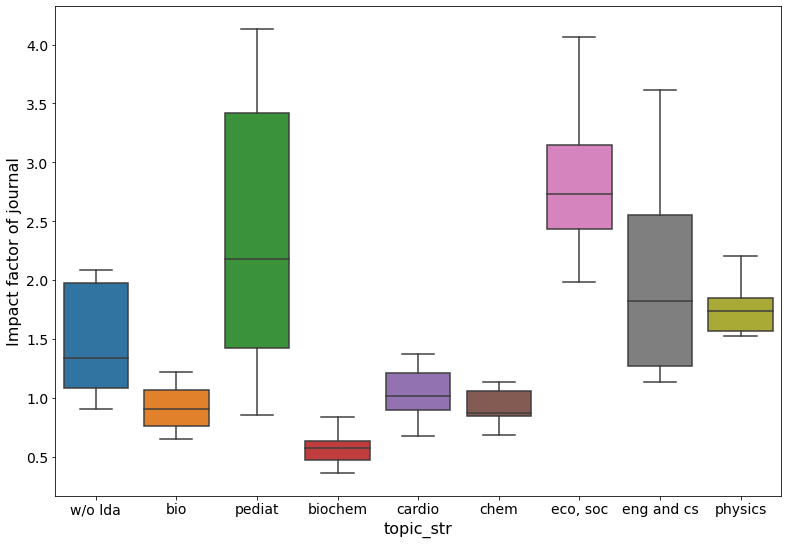

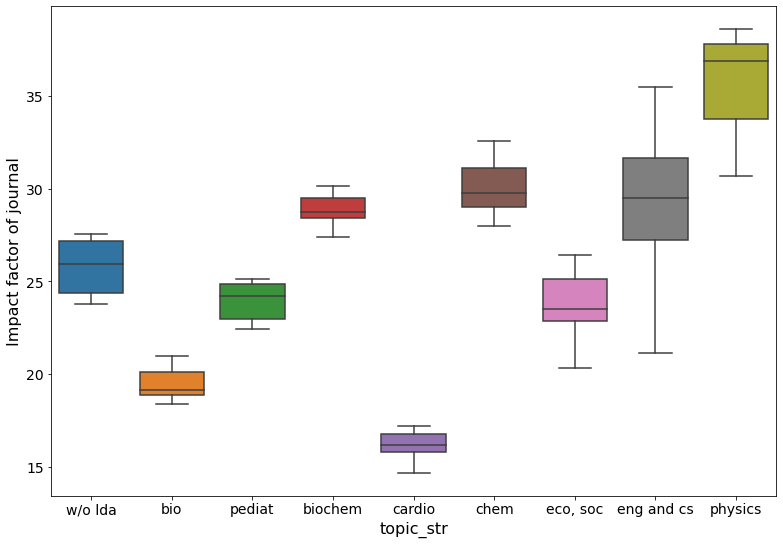

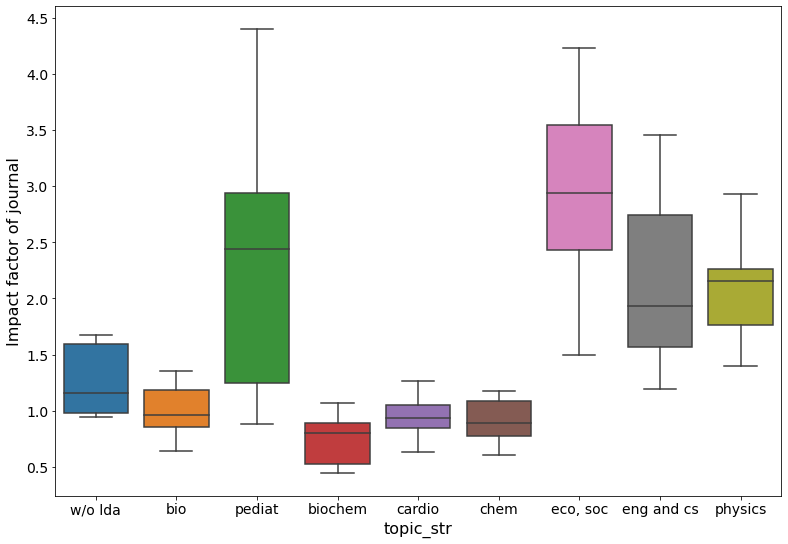

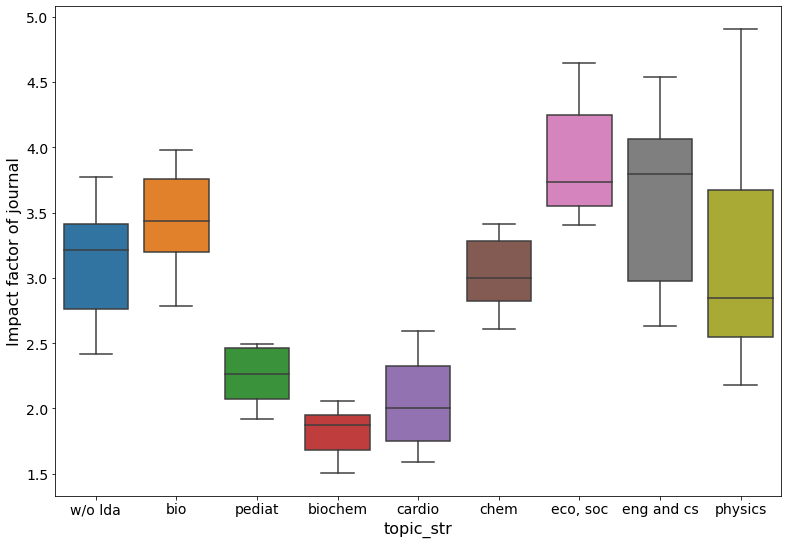

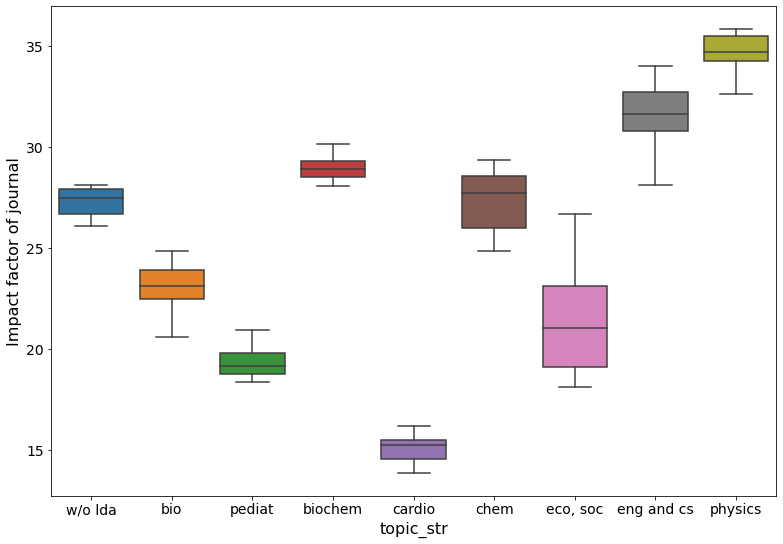

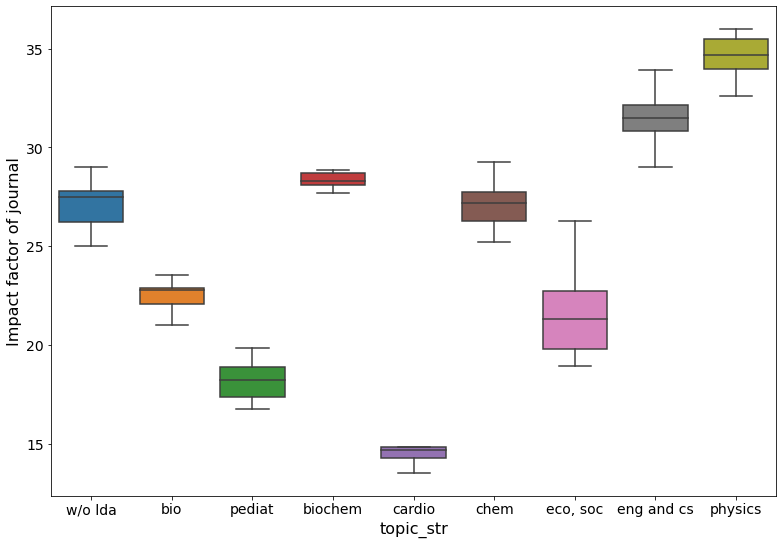

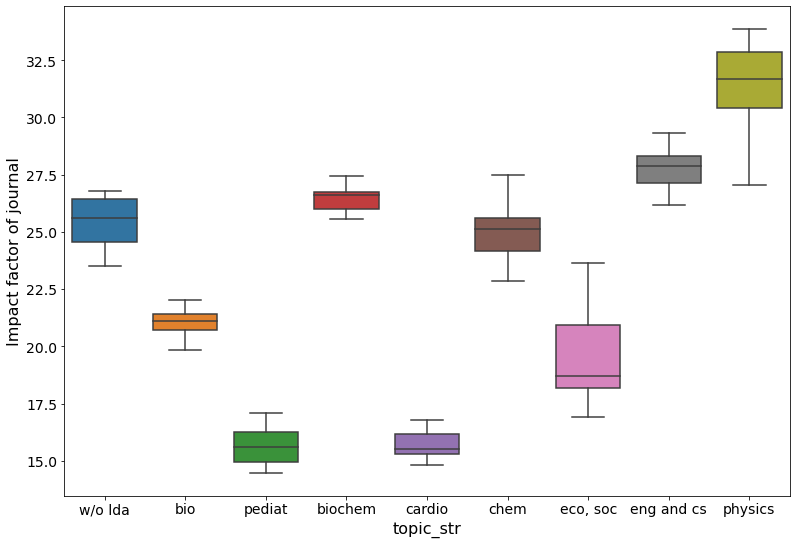

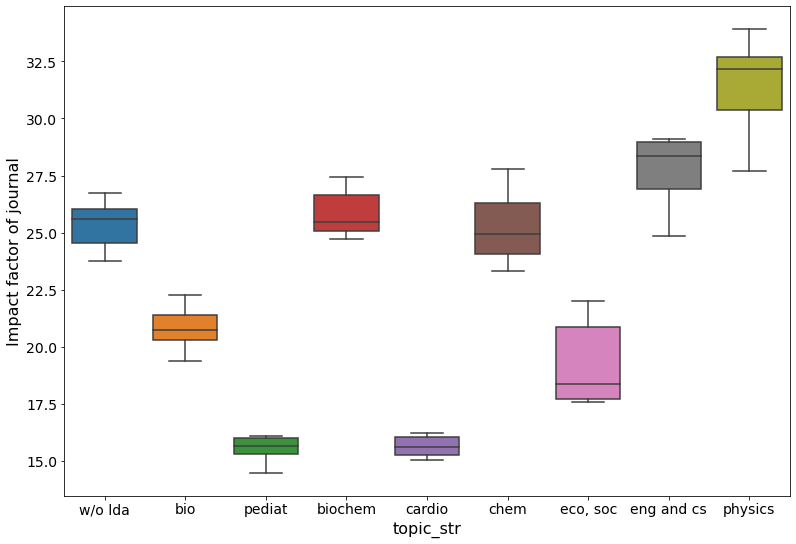

In [352]:
themd_d = {
    1: 'bio',
    4: 'cardio',
    2: 'pediat',
    3: 'biochem',
    5: 'chem',
    6: 'eco, soc',
    7: 'eng and cs',
    8: 'physics',
    0: 'w/o lda'
}




for key in dd:
    for col in dd[key]:
        if col != 'topic_str' and col == 'Impact factor of journal':
            plt.figure()
    #         plt.title(key)
            dd[key]['topic_str'] = dd[key]['topic'].apply(lambda x: themd_d[x])
            if 'c_all' in dd[key].columns:
                dd[key]['Total citations'] = dd[key]['c_all']
            if 'year' in dd[key].columns:
                dd[key]['Year of publication'] = dd[key].year
            if 'c2' in dd[key].columns:
                dd[key]['Two year citations'] = dd[key].c2
            if 'avg_citations_paper' in dd[key].columns:
                dd[key]['Impact factor of journal'] = dd[key]['avg_citations_paper']
            ax = sns.boxplot(x='topic_str', y=col, data=dd[key], showfliers = False)

In [346]:
ls = [(x, y) for x, y in zip(y_test_all, catb_model.predict(X_test_all))]
ls.sort()
plt.scatter(list(range(len([x for x, y in ls if x > 100]))), [x for x, y in ls if x > 100])
plt.scatter(list(range(len([x for x, y in ls if x > 100]))), [y for x, y in ls if x > 100])

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=6]="en": Cannot convert 'b'en'' to float

In [230]:
mean_absolute_percentage_error(y_test_all, catb_model.predict(X_test_all))

1038054416861042.6

In [231]:
catb_model.predict(X_test_all)

array([-0.2582808 , -0.25659019,  0.11463038, ...,  0.15084684,
       -0.17485144,  0.08389229])

(array([141317.,  22303.,  12157.,   8323.,   6171.,   4855.,   4160.,
          3590.,   3134.,   2789.,  10064.,   6438.,   8162.,   7731.,
          6178.]),
 array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  15,  20,
         30,  50, 100]),
 <BarContainer object of 15 artists>)

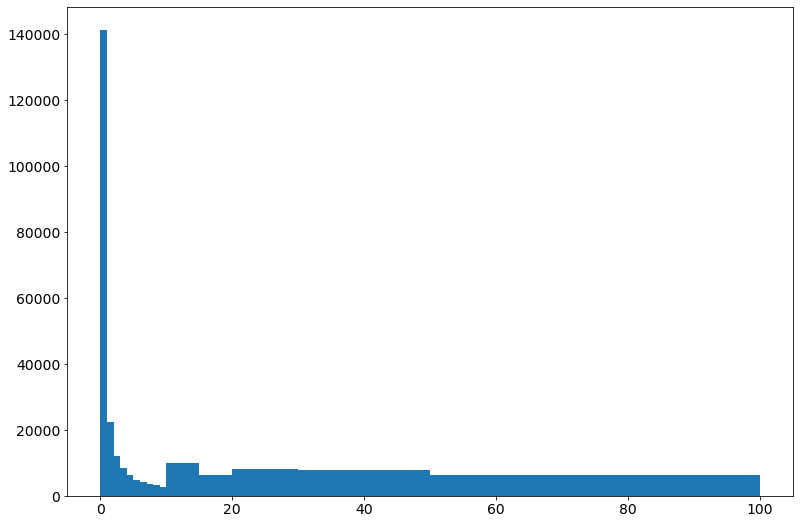

In [234]:
plt.hist(y_test_all, bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50, 100])

(array([58659., 86609., 19570., 11767.,  8385.,  5926.,  5037.,  4004.,
         3336.,  2954.,  2738.,  9865.,  6683.,  8196.,  7651.,  6065.]),
 array([-10000,      0,      1,      2,      3,      4,      5,      6,
             7,      8,      9,     10,     15,     20,     30,     50,
           100]),
 <BarContainer object of 16 artists>)

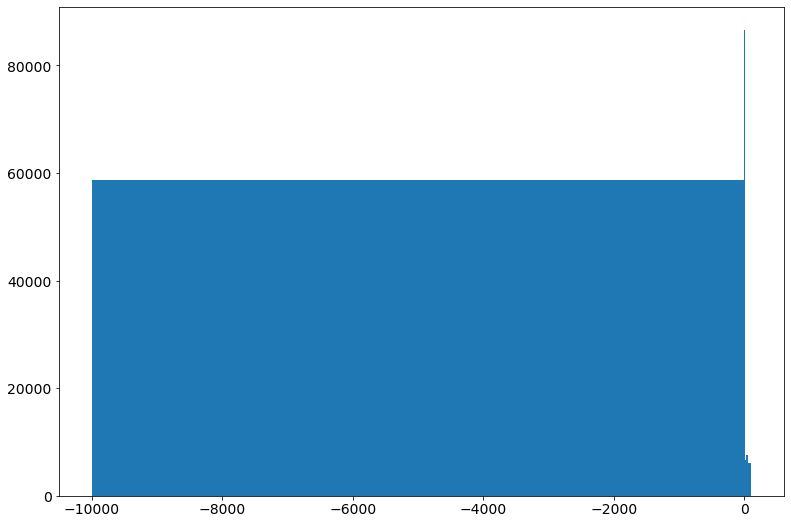

In [237]:
plt.hist(catb_model.predict(X_test_all), bins=[-10000, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30, 50, 100])

In [238]:
ls = catb_model.predict(X_test_all)

In [241]:
sum([i < 0 for i in ls]), len(ls)

(58659, 251419)

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe76b2bd790>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe76b2b8990>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe76b2bd950>],
 'medians': [<matplotlib.lines.Line2D at 0x7fe76b2b81d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fe76b2b4910>],
 'means': []}

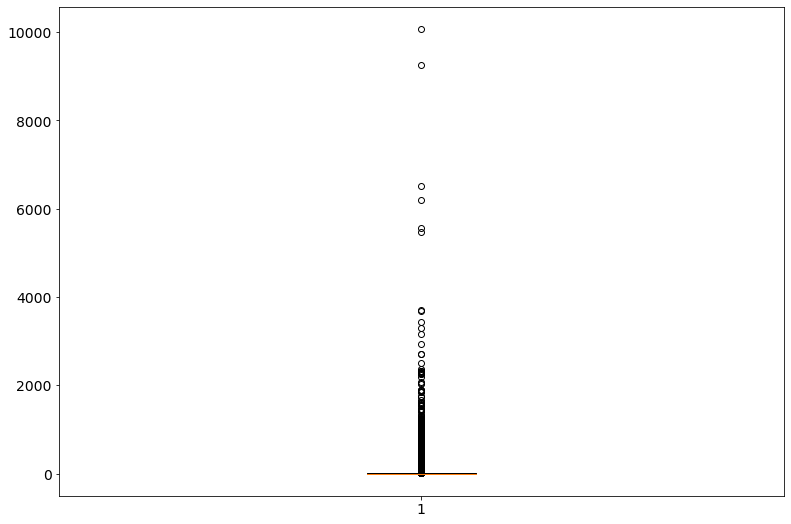

In [244]:
# plt.boxplot(ls)
plt.boxplot(y_test_all)

In [245]:
mean_absolute_percentage_error(y_test_all.values, ls)

1038054416861042.6

In [248]:
mape = 0
ll = []
eps = 1e-6
for x, y in zip(ls, y_test_all):
    ll.append((abs(x - y) / max(eps, abs(y)), x, y))


In [250]:
ll[:100]

[(258280.7984496185, -0.2582807984496185, 0),
 (256590.1910240367, -0.2565901910240367, 0),
 (114630.38338039943, 0.11463038338039944, 0),
 (0.6822397894694356, 1.6822397894694356, 1),
 (464906.2197468368, -0.46490621974683677, 0),
 (100578.63702431115, -0.10057863702431113, 0),
 (57790.41373900285, 0.057790413739002844, 0),
 (269189.2334918968, 0.26918923349189683, 0),
 (480921.591390473, -0.48092159139047297, 0),
 (36805.26931772121, -0.03680526931772121, 0),
 (2151.7972687377096, -0.0021517972687377096, 0),
 (0.3741064478319784, 9.618745134823849, 7),
 (127617.00794839293, 0.12761700794839292, 0),
 (66372.88695856469, -0.06637288695856469, 0),
 (0.4721041495325079, 57.41206183176781, 39),
 (76608.9350062309, -0.0766089350062309, 0),
 (0.42275967936327774, 0.5772403206367223, 1),
 (0.15800717755470045, 5.790035887773502, 5),
 (0.10733726162195752, 3.3220117848658726, 3),
 (0.060686292030948115, 69.50921438970984, 74),
 (165993.86308444155, 0.16599386308444153, 0),
 (0.295173383232862

In [124]:
%%time
cross_validate(catb_model, X_train_all, y_train_all, scoring=['neg_root_mean_squared_error', 'r2'], cv=5)

Learning rate set to 0.128279
0:	learn: 16.8331420	total: 38.4ms	remaining: 38.4s
100:	learn: 4.9553551	total: 3.95s	remaining: 35.2s
200:	learn: 4.6405533	total: 7.85s	remaining: 31.2s
300:	learn: 4.4642202	total: 11.7s	remaining: 27.3s
400:	learn: 4.3369423	total: 15.6s	remaining: 23.3s
500:	learn: 4.2310886	total: 19.5s	remaining: 19.4s
600:	learn: 4.1442164	total: 23.3s	remaining: 15.5s
700:	learn: 4.0687232	total: 27.2s	remaining: 11.6s
800:	learn: 4.0001016	total: 31s	remaining: 7.71s
900:	learn: 3.9422912	total: 34.9s	remaining: 3.83s
999:	learn: 3.8852802	total: 38.7s	remaining: 0us
Learning rate set to 0.128279
0:	learn: 16.8721880	total: 38.5ms	remaining: 38.5s
100:	learn: 4.9669888	total: 3.93s	remaining: 35s
200:	learn: 4.6518660	total: 7.83s	remaining: 31.1s
300:	learn: 4.4740764	total: 11.7s	remaining: 27.2s
400:	learn: 4.3378827	total: 15.6s	remaining: 23.3s
500:	learn: 4.2357122	total: 19.5s	remaining: 19.4s
600:	learn: 4.1456026	total: 23.3s	remaining: 15.5s
700:	learn

{'fit_time': array([39.27414274, 39.1791091 , 39.2680614 , 39.38260579, 39.19132495]),
 'score_time': array([0.14262891, 0.09926581, 0.09936047, 0.16006422, 0.15069175]),
 'test_neg_root_mean_squared_error': array([-4.38857822, -4.41602694, -4.38583414, -4.44282773, -4.41956341]),
 'test_r2': array([0.94593403, 0.94415231, 0.94591157, 0.94364254, 0.94366452])}

In [119]:
%%time
cross_val_model(catb_model, X_train_all, y_train_all, scoring='neg_root_mean_squared_error', cv=5)

Learning rate set to 0.128279
0:	learn: 16.8331420	total: 37.9ms	remaining: 37.9s
100:	learn: 4.9553551	total: 3.95s	remaining: 35.1s
200:	learn: 4.6405533	total: 7.85s	remaining: 31.2s
300:	learn: 4.4642202	total: 11.7s	remaining: 27.2s
400:	learn: 4.3369423	total: 15.6s	remaining: 23.3s
500:	learn: 4.2310886	total: 19.5s	remaining: 19.4s
600:	learn: 4.1442164	total: 23.3s	remaining: 15.5s
700:	learn: 4.0687232	total: 27.2s	remaining: 11.6s
800:	learn: 4.0001016	total: 31s	remaining: 7.71s
900:	learn: 3.9422912	total: 34.9s	remaining: 3.83s
999:	learn: 3.8852802	total: 38.7s	remaining: 0us
Learning rate set to 0.128279
0:	learn: 16.8721880	total: 37.5ms	remaining: 37.5s
100:	learn: 4.9669888	total: 3.94s	remaining: 35s
200:	learn: 4.6518660	total: 7.83s	remaining: 31.1s
300:	learn: 4.4740764	total: 11.7s	remaining: 27.2s
400:	learn: 4.3378827	total: 15.6s	remaining: 23.3s
500:	learn: 4.2357122	total: 19.4s	remaining: 19.3s
600:	learn: 4.1456026	total: 23.2s	remaining: 15.4s
700:	learn

In [122]:
np.mean(y_train_all)

6.8333040014079325

In [95]:
columns_c5 = [item for item in X_train_c5.columns if item not in {'mean_citations', 'top_citations'}]
columns_c2 = [item for item in X_train_c2.columns if item not in {'mean_citations', 'top_citations'}]
columns_all = [item for item in X_train_all.columns if item not in {'mean_citations', 'top_citations'}]

In [97]:
%%time
cross_val_model(catb_model, X_train_all[columns_all], y_train_all, scoring='r2', cv=5)

Learning rate set to 0.128279
0:	learn: 17.0454524	total: 37.9ms	remaining: 37.9s
100:	learn: 8.3305733	total: 3.87s	remaining: 34.4s
200:	learn: 8.2048228	total: 7.69s	remaining: 30.6s
300:	learn: 8.1259094	total: 11.5s	remaining: 26.8s
400:	learn: 8.0617417	total: 15.4s	remaining: 23s
500:	learn: 8.0089076	total: 19.2s	remaining: 19.1s
600:	learn: 7.9608542	total: 23s	remaining: 15.3s
700:	learn: 7.9131613	total: 26.9s	remaining: 11.5s
800:	learn: 7.8721515	total: 30.7s	remaining: 7.63s
900:	learn: 7.8329675	total: 34.5s	remaining: 3.79s
999:	learn: 7.7917859	total: 38.3s	remaining: 0us
Learning rate set to 0.128279
0:	learn: 17.0872149	total: 38.4ms	remaining: 38.3s
100:	learn: 8.3410025	total: 3.85s	remaining: 34.3s
200:	learn: 8.2129475	total: 7.71s	remaining: 30.6s
300:	learn: 8.1391308	total: 11.5s	remaining: 26.7s
400:	learn: 8.0815144	total: 15.3s	remaining: 22.9s
500:	learn: 8.0281482	total: 19.1s	remaining: 19s
600:	learn: 7.9745846	total: 22.9s	remaining: 15.2s
700:	learn: 

In [99]:
%%time
cross_val_model(catb_model, X_train_c5, y_train_c5, scoring='r2', cv=5)

Learning rate set to 0.128203
0:	learn: 5.4567946	total: 39ms	remaining: 38.9s
100:	learn: 1.7397098	total: 3.96s	remaining: 35.2s
200:	learn: 1.6823252	total: 7.86s	remaining: 31.2s
300:	learn: 1.6491920	total: 11.7s	remaining: 27.1s
400:	learn: 1.6249899	total: 15.6s	remaining: 23.3s
500:	learn: 1.6052193	total: 19.5s	remaining: 19.4s
600:	learn: 1.5886200	total: 23.3s	remaining: 15.5s
700:	learn: 1.5750020	total: 27.1s	remaining: 11.6s
800:	learn: 1.5630641	total: 30.9s	remaining: 7.68s
900:	learn: 1.5504377	total: 34.7s	remaining: 3.81s
999:	learn: 1.5393834	total: 38.5s	remaining: 0us
Learning rate set to 0.128203
0:	learn: 5.4694808	total: 38.4ms	remaining: 38.3s
100:	learn: 1.7436912	total: 3.96s	remaining: 35.2s
200:	learn: 1.6842495	total: 7.89s	remaining: 31.4s
300:	learn: 1.6516881	total: 11.8s	remaining: 27.3s
400:	learn: 1.6293908	total: 15.6s	remaining: 23.3s
500:	learn: 1.6097394	total: 19.5s	remaining: 19.4s
600:	learn: 1.5937552	total: 23.3s	remaining: 15.5s
700:	learn

In [100]:
%%time
cross_val_model(catb_model, X_train_c2, y_train_c2, scoring='r2', cv=5)

Learning rate set to 0.131618
0:	learn: 2.4637677	total: 50.5ms	remaining: 50.5s
100:	learn: 1.5390906	total: 4.7s	remaining: 41.8s
200:	learn: 1.4975526	total: 9.36s	remaining: 37.2s
300:	learn: 1.4758157	total: 14s	remaining: 32.5s
400:	learn: 1.4603393	total: 18.5s	remaining: 27.7s
500:	learn: 1.4476624	total: 23.1s	remaining: 23s
600:	learn: 1.4372205	total: 27.6s	remaining: 18.3s
700:	learn: 1.4274863	total: 32.1s	remaining: 13.7s
800:	learn: 1.4185533	total: 36.6s	remaining: 9.09s
900:	learn: 1.4108152	total: 41.1s	remaining: 4.51s
999:	learn: 1.4036074	total: 45.6s	remaining: 0us
Learning rate set to 0.131618
0:	learn: 2.4644664	total: 50.1ms	remaining: 50.1s
100:	learn: 1.5385324	total: 4.72s	remaining: 42s
200:	learn: 1.4978795	total: 9.32s	remaining: 37.1s
300:	learn: 1.4762659	total: 13.9s	remaining: 32.3s
400:	learn: 1.4603976	total: 18.5s	remaining: 27.6s
500:	learn: 1.4471850	total: 23s	remaining: 23s
600:	learn: 1.4362332	total: 27.6s	remaining: 18.3s
700:	learn: 1.42702

In [112]:
columns_all

['year',
 'c2',
 'c5',
 'num_of_authors',
 'num_words_title',
 'num_words_abs',
 'productivity',
 'is_main_ratio',
 'sociality',
 'total_venues',
 'h_1970',
 'h_1980',
 'h_1990',
 'h_2000',
 'h_2010',
 'h_2020',
 'total_papers',
 'total_citations',
 'avg_citations_paper',
 'avg_citations_year',
 'avg_papers_year',
 'None',
 'de',
 'en',
 'es',
 'fr',
 'ja',
 'ko',
 'pt',
 'zh-cn']

In [114]:
%%time
cross_val_model(catb_model, X_train_all[columns_all[:1] + columns_all[3:]], y_train_all, scoring='r2', cv=5)

Learning rate set to 0.128279
0:	learn: 17.9383829	total: 43.8ms	remaining: 43.8s
100:	learn: 14.3377516	total: 4.06s	remaining: 36.1s
200:	learn: 14.1757207	total: 7.92s	remaining: 31.5s
300:	learn: 14.0727101	total: 11.7s	remaining: 27.3s
400:	learn: 13.9937822	total: 15.6s	remaining: 23.2s
500:	learn: 13.9263613	total: 19.3s	remaining: 19.3s
600:	learn: 13.8652382	total: 23.1s	remaining: 15.3s
700:	learn: 13.8109280	total: 26.9s	remaining: 11.5s
800:	learn: 13.7599036	total: 30.7s	remaining: 7.64s
900:	learn: 13.7094353	total: 34.5s	remaining: 3.79s
999:	learn: 13.6602933	total: 38.5s	remaining: 0us
Learning rate set to 0.128279
0:	learn: 17.9788178	total: 43.8ms	remaining: 43.8s
100:	learn: 14.3553830	total: 4.05s	remaining: 36s
200:	learn: 14.1895314	total: 7.92s	remaining: 31.5s
300:	learn: 14.0909412	total: 11.8s	remaining: 27.3s
400:	learn: 14.0066881	total: 15.6s	remaining: 23.3s
500:	learn: 13.9379494	total: 19.4s	remaining: 19.3s
600:	learn: 13.8757418	total: 23.2s	remaining

In [101]:
X_train_c5.head()

,year,c2,num_of_authors,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,mean_citations,...,avg_papers_year,None,de,en,es,fr,ja,ko,pt,zh-cn
idx,,,,,,,,,,,,,,,,,,,,,
a0cad141c9441f02fd77303914efc6803c9695d7,1995.0,0,1,9,0,0.037037,1.000000,0.000000,1.0,0.000000,...,1.285714,0,0,1,0,0,0,0,0,0
e1bd5efb16b8eb6642a827d03d2bc2a02002155b,1991.0,2,2,10,36,0.080645,0.583333,0.916667,2.5,15.166667,...,2.087719,0,0,1,0,0,0,0,0,0
4bf302d6f7f25110bb8b4f2006a6876367e98c67,1964.0,0,1,8,0,0.017241,1.000000,0.000000,0.0,0.000000,...,0.000000,0,1,0,0,0,0,0,0,0
042e1c0bbe9a148fbf19fad0c172372fca1f05c9,2010.0,1,5,11,121,1.936404,0.138889,4.361111,34.0,5.687500,...,8.000000,0,0,1,0,0,0,0,0,0
0a6793746ab70188320bf65998f46aea240af15d,1996.0,15,5,12,209,0.103147,0.366667,3.633333,4.0,20.233333,...,1.000000,0,0,1,0,0,0,0,0,0


In [103]:
X_train_c2.head()

,year,num_of_authors,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,mean_citations,top_citations,...,None,de,en,es,fr,it,ja,ko,pt,zh-cn
idx,,,,,,,,,,,,,,,,,,,,,
d9c076f187ad5ab26bdc49254f5af2c605be915b,2018.0,3,15,0,0.250000,0.500000,2.000000,0.0,2.0,2.0,...,0,0,1,0,0,0,0,0,0,0
f26b232b730da62640a0d952e84ec0649094fd79,2009.0,2,4,207,0.145604,0.666667,1.166667,0.0,1.5,3.0,...,0,1,0,0,0,0,0,0,0,0
b28d53d708764494038d1c0d00d2f8d95edab9eb,1916.0,1,7,0,0.009434,1.000000,0.000000,1.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
d32e0ae906df45e2eab810ffd3c267a20bd5be95,2012.0,1,9,0,0.100000,1.000000,0.000000,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
5d4070df9721760e0474ac985360c769f94c2194,2009.0,5,15,0,0.076923,0.500000,4.000000,0.0,0.0,0.0,...,1,0,0,0,0,0,0,0,0,0


In [104]:
X_train_all.head()

,year,c2,c5,num_of_authors,num_words_title,num_words_abs,productivity,is_main_ratio,sociality,total_venues,...,avg_papers_year,None,de,en,es,fr,ja,ko,pt,zh-cn
idx,,,,,,,,,,,,,,,,,,,,,
a0cad141c9441f02fd77303914efc6803c9695d7,1995.0,0,0,1,9,0,0.037037,1.000000,0.000000,1.0,...,1.285714,0,0,1,0,0,0,0,0,0
e1bd5efb16b8eb6642a827d03d2bc2a02002155b,1991.0,2,4,2,10,36,0.080645,0.583333,0.916667,2.5,...,2.087719,0,0,1,0,0,0,0,0,0
4bf302d6f7f25110bb8b4f2006a6876367e98c67,1964.0,0,0,1,8,0,0.017241,1.000000,0.000000,0.0,...,0.000000,0,1,0,0,0,0,0,0,0
042e1c0bbe9a148fbf19fad0c172372fca1f05c9,2010.0,1,2,5,11,121,1.936404,0.138889,4.361111,34.0,...,8.000000,0,0,1,0,0,0,0,0,0
0a6793746ab70188320bf65998f46aea240af15d,1996.0,15,22,5,12,209,0.103147,0.366667,3.633333,4.0,...,1.000000,0,0,1,0,0,0,0,0,0


In [76]:
%%time
cross_val_model(grad_pipe, X_train, y_train, scoring='r2', cv=5)

r2 = 0.6911308487726918 +- 0.0023152929105895153
CPU times: user 15min 34s, sys: 302 ms, total: 15min 34s
Wall time: 15min 34s


In [151]:
catb_model.fit(X_train_all, y_train_all)

Learning rate set to 0.13361
0:	learn: 57.8408117	total: 41.3ms	remaining: 41.3s
100:	learn: 20.3309341	total: 4.39s	remaining: 39s
200:	learn: 15.3593131	total: 8.73s	remaining: 34.7s
300:	learn: 12.4356371	total: 13.3s	remaining: 30.8s
400:	learn: 10.7266744	total: 17.8s	remaining: 26.6s
500:	learn: 9.5943730	total: 22.5s	remaining: 22.4s
600:	learn: 8.8224345	total: 27.1s	remaining: 18s
700:	learn: 8.2388781	total: 31.8s	remaining: 13.6s
800:	learn: 7.7849581	total: 36.4s	remaining: 9.04s
900:	learn: 7.4518270	total: 41s	remaining: 4.51s
999:	learn: 7.1479589	total: 45.7s	remaining: 0us


In [152]:
r2_score(y_test_all, catb_model.predict(X_test_all))

0.8225698030485568

In [153]:
list(zip(map(float, catb_model.get_feature_importance()), X_train_all.columns))

[(7.780177575445732, 'year'),
 (2.4552250687901536, 'c2'),
 (28.454364214742604, 'c5'),
 (0.40429116557520123, 'num_of_authors'),
 (1.6948447924680756, 'num_words_title'),
 (1.1382032171610124, 'num_words_abs'),
 (5.250107984280469, 'productivity'),
 (0.9995987764946099, 'is_main_ratio'),
 (0.49061038994780254, 'sociality'),
 (0.9298071647321524, 'total_venues'),
 (15.618889258631466, 'mean_citations'),
 (23.327211627872348, 'top_citations'),
 (0.229963479469077, 'h_1970'),
 (0.39383710234136743, 'h_1980'),
 (0.5511314773235757, 'h_1990'),
 (0.9170017431045515, 'h_2000'),
 (0.4237002014278554, 'h_2010'),
 (0.8002339448361858, 'h_2020'),
 (0.7789186731581321, 'total_papers'),
 (3.538597394304745, 'total_citations'),
 (2.353803335854469, 'avg_citations_paper'),
 (1.1999275704791288, 'avg_citations_year'),
 (0.2611078530322724, 'avg_papers_year'),
 (0.007189628197432335, 'None'),
 (0.00047749700402921307, 'de'),
 (0.0, 'en'),
 (0.0, 'es'),
 (0.0, 'fr'),
 (0.0003439474955477541, 'ja'),
 (0

In [155]:
ls = [(x, y) for x, y in zip(y_test_all, catb_model.predict(X_test_all))]
ls.sort()

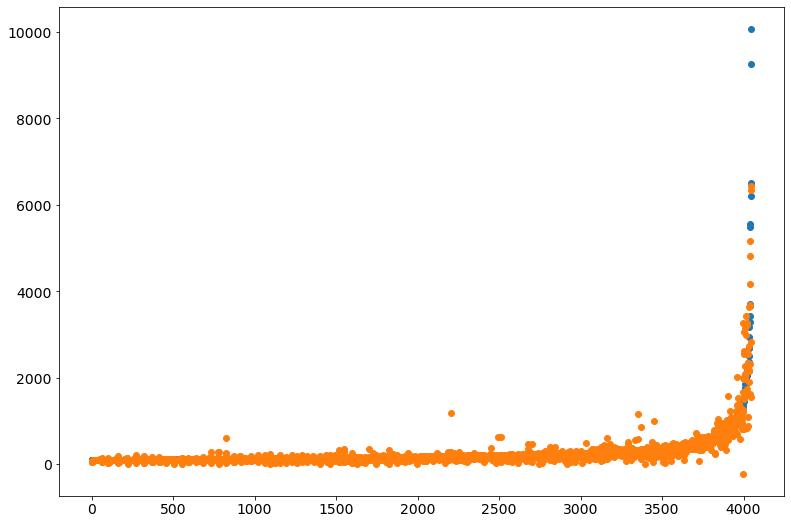

In [158]:
plt.scatter(list(range(len([x for x, y in ls if x > 100]))), [x for x, y in ls if x > 100])
plt.scatter(list(range(len([x for x, y in ls if x > 100]))), [y for x, y in ls if x > 100])

<AxesSubplot:xlabel='mean_citations', ylabel='Count'>

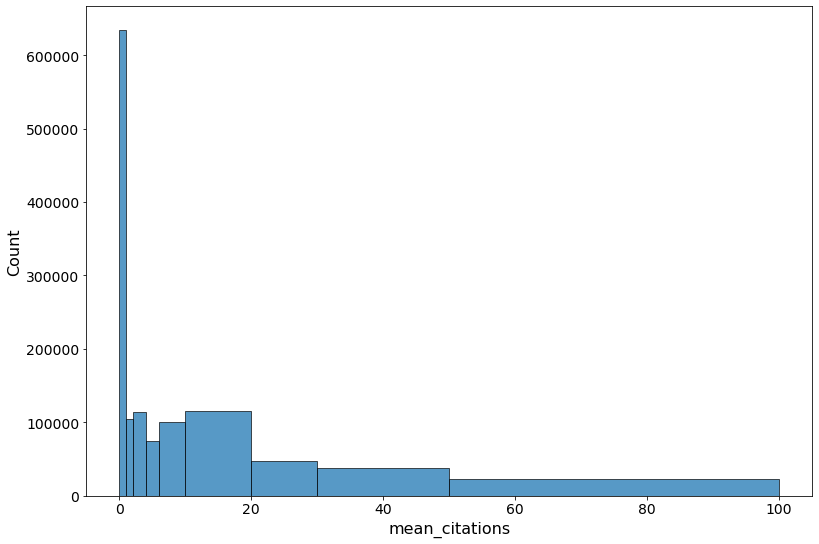

In [38]:
sns.histplot(X_train.mean_citations, bins=[0, 1, 2, 4, 6, 10, 20, 30, 50, 100])

<AxesSubplot:xlabel='top_citations', ylabel='Count'>

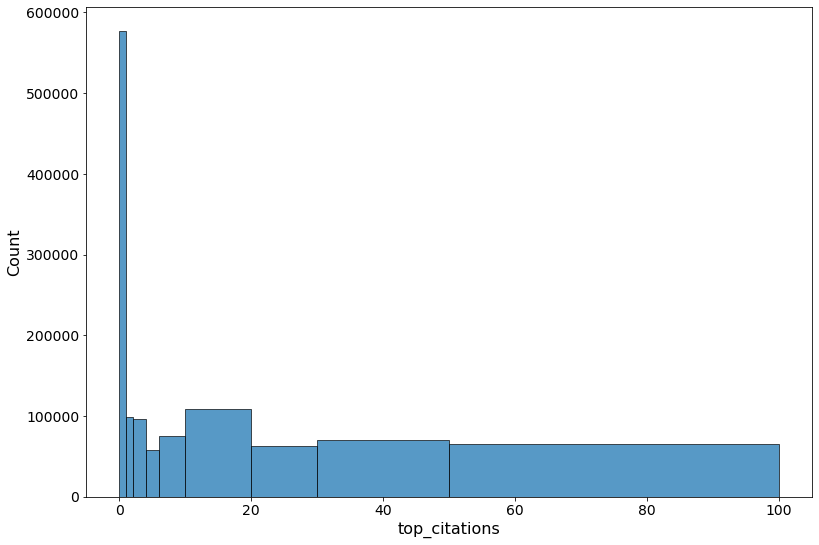

In [40]:
sns.histplot(X_train.top_citations, bins=[0, 1, 2, 4, 6, 10, 20, 30, 50, 100])

<AxesSubplot:xlabel='mean_citations', ylabel='Count'>

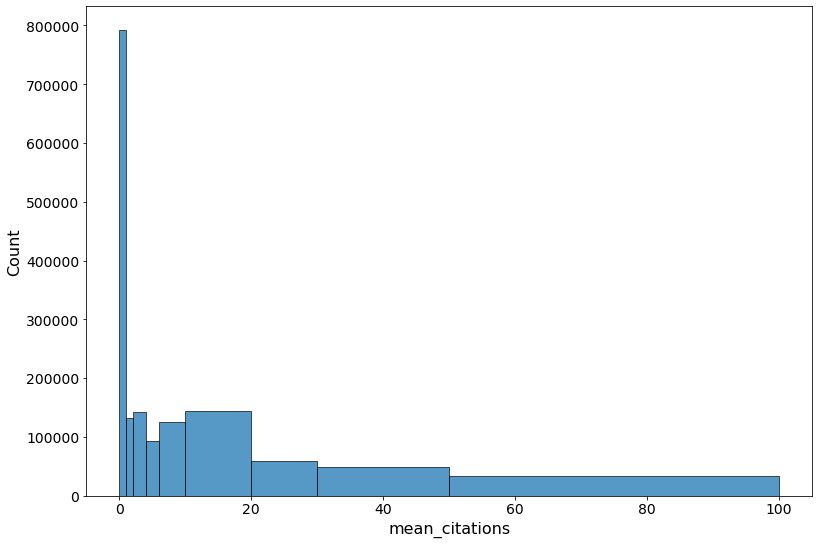

In [42]:
sns.histplot(df.mean_citations, bins=[0, 1, 2, 4, 6, 10, 20, 30, 50, 100])

In [110]:
ls = list(df[df.dominant_topic == 1].index)

In [118]:
q = f'''select distinct ssid, venue_id from venues_papers_authors where ssid in ({", ".join(map(lambda x: f"'{x}'", ls))})'''

In [119]:
q[:1000]

"select distinct ssid, venue_id from venues_papers_authors where ssid in ('0826e1b527c9cd460a3c672ce152c2f0447688e8', '5b2b604b529d6d3c24a45b6753d6c139c32f86c3', '405b5a841b088ea8463a0b8477f8d5d0da2ab125', '619831552aeefbcc9b8ed0b51950915168177c12', '18dc99cd926d553c29a86f4208900f91543fe4c9', '478649e5f9a8c9eee8e8cd175f1d276cdcd45016', '2035de1612c0bfcc1a61e83477987aa772a5ea63', '52f39cd268411b43979e0813fc08e0edf1c8bc00', '007b9af4bddf7e2569c7ff796142173ed85e5002', '81d339796ae6006bb4d15dfd397cdd3f4d8fc8ff', '828e25c7f6a84368b85726118af8e261f0b60870', '0040f662de9792c99a53a185bc6972976613c362', '0041884968ab179daf84658f76c8f6064109d457', '00479cdf3f4a47de1c3fed88fe78c2a3fb3f042e', '00481671388f139907e024a3d334867845c883b5', '0049159047dc2dc342707c5edd50b61c81c2e419', '004ed751f1bbeb1eb220e8c50cfc6f8b8087f4f4', '005f4a0a2ca2ecf088038f18e3dfd8b9c41cc8ee', '00670dd351af76deb2e14a929b83eaaec8879c67', '0067b20d60a3f61a3ad813a2385de55be2c86fbf', '006b623bde9515205cceeda61ec374f83da80380', '0

In [314]:
import logging

import numpy as np
import pandas as pd

from pysrc.papers.db.loader import Loader
from pysrc.papers.db.postgres_connector import PostgresConnector
from pysrc.papers.db.postgres_utils import preprocess_search_query_for_postgres, \
    process_bibliographic_coupling_postgres, process_cocitations_postgres, no_stemming_filter
from pysrc.papers.utils import crc32, SORT_MOST_CITED, SORT_MOST_RECENT, preprocess_doi, \
    preprocess_search_title

logger = logging.getLogger(__name__)

import logging
import html
import pandas as pd
import numpy as np
import networkx as nx
import random
import hashlib
from tqdm.auto import tqdm

from pysrc.prediction.ss_arxiv_loader import SSArxivLoader
from pysrc.prediction.ss_pubmed_loader import SSPubmedLoader
from pysrc.papers.db.pm_postgres_loader import PubmedPostgresLoader
from pysrc.prediction.predict_analyzer import PredictAnalyzer
from pysrc.papers.config import PubtrendsConfig
from pysrc.papers.db.ss_postgres_loader import SemanticScholarPostgresLoader
from pysrc.papers.db.postgres_connector import PostgresConnector
from collections import defaultdict



class CustomLoader(SemanticScholarPostgresLoader):
    def __init__(self, config):
        super(CustomLoader, self).__init__(config)

    def load_func(self, limit=100):
        self.check_connection()
        if limit is None:
            query = '''SELECT ssid, aux::json->'authors' FROM sspublications'''
        else:
            query = f'''
                    SELECT ssid, aux::json->'authors' FROM sspublications LIMIT {limit}
            '''
        result = defaultdict(list)
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            for item in cursor:
                ind, names = item
                for i, el in enumerate(names):
                    result[el['name']].append((ind, int(i == 0)))
            return result
    
    def custom_query(self, query):
        self.check_connection()
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            return cursor.fetchall()
    
    def create_subsample(self, threshold=0.01, seed=42):
        self.check_connection()
        random.seed(seed)
        ssids, crc32ids = [], []
        query = '''select ssid, crc32id from sspublications'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            for item in cursor:
                if random.random() < threshold:
                    ss, crc = item
                    ssids.append(ss)
                    crc32ids.append(crc)
            return ssids, crc32ids


class CustomWriter(PostgresConnector):

    def __init__(self, config):
        super(CustomWriter, self).__init__(config, readonly=False)
        
    def insert_table_publications(self, ids):
        self.check_connection()
        query = f'''CREATE TABLE IF NOT EXISTS sspublications_sample AS 
            (SELECT * FROM sspublications WHERE ssid IN ({', '.join(map(lambda x: "'" + str(x) + "'", ids))}))'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            self.postgres_connection.commit()
        
    def insert_table_citations(self, ids):
        self.check_connection()
        query = f'''CREATE TABLE IF NOT EXISTS sscit_sample AS 
            (SELECT * FROM sscitations WHERE crc32id_in IN ({', '.join(map(lambda x: "'" + str(x) + "'", ids))}));
            create index if not exists sscit_crc32id_in on sscit_sample (crc32id_in);'''
        with self.postgres_connection.cursor() as cursor:
            cursor.execute(query)
            self.postgres_connection.commit()
    
    def execute_custom_query(self, query):
        try:
            self.check_connection()
            with self.postgres_connection.cursor() as cursor:
                cursor.execute(query)
                self.postgres_connection.commit()
        except Exception as e:
            print(e)




In [320]:
config = PubtrendsConfig(test=False)
loader = CustomLoader(config)
writer = CustomWriter(config)

In [321]:
def get_journals_info(df, n_tops=5):
    ans = {}
    for i in tqdm(range(8)):
        ls = list(df[df.dominant_topic == i + 1].index)
        q = f'''select distinct ssid, venue_id from venues_papers_authors where ssid in ({", ".join(map(lambda x: f"'{x}'", ls))})'''
        res = loader.custom_query(q)
        vens = [y for x, y in res]
        d = Counter(vens).most_common(n_tops)
        ls = [x for x, y in d]
        q = f'''select venue_name, total_citations, total_papers from venues where venue_id in ({', '.join(map(str, ls))}) order by total_citations desc;'''
        ans[i + 1] = loader.custom_query(q)
    return ans

In [322]:
top_journals = get_journals_info(df, n_tops=15)

In [323]:
top_journals

{1: [('plos one', 40333, 2180),
  ('journal of geophysical research', 36954, 867),
  ('environmental science & technology', 16007, 380),
  ('scientific reports', 12938, 1041),
  ('geophysical research letters', 11604, 328),
  ('chemosphere', 8552, 280),
  ('the science of the total environment', 7576, 342),
  ('plant and soil', 4177, 161),
  ('forest ecology and management', 3979, 140),
  ('hydrobiologia', 3043, 216),
  ('biorxiv', 2108, 982),
  ('environmental science and pollution research', 1910, 190),
  ('advanced materials research', 1184, 1172),
  ('zootaxa', 1111, 224),
  ('journal of anhui agricultural sciences', 55, 242)],
 2: [('circulation', 41459, 826),
  ('plos one', 40333, 2180),
  ('pediatrics', 14343, 412),
  ('bmj : british medical journal', 7810, 486),
  ('the cochrane database of systematic reviews', 6677, 127),
  ('archives of disease in childhood', 4486, 293),
  ('personality and individual differences', 3829, 132),
  ('journal of affective disorders', 3490, 125),


In [125]:
res = loader.custom_query(q)
vens = [y for x, y in res]

In [126]:
vens[:10]

[19068, 35874, 28423, 24204, 42942, 44114, 34167, 4234, 10283, 1817]

In [127]:
from collections import Counter

In [128]:
Counter(vens).most_common(5)

[(8628, 105), (1370, 58), (408, 55), (1950, 54), (4620, 51)]

In [282]:
list(results.keys())

['c_all_from_c2_c5_mean_top',
 'c_all_without_c2_c5',
 'c_all_without_mean_top',
 'c_5_from_c2_mean_top',
 'c_5_without_c2',
 'c_5_without_c2_mean_top',
 'c_2_from_mean_top',
 'c_2_without_mean_top']

In [309]:
np.mean(results_top3['c_2_from_mean_top']['rmse']), np.std(results_top3['c_2_from_mean_top']['rmse'])

(10.544502743960386, 0.41152713403286556)

In [303]:
data_for_box[8]['c_all_without_c2_c5']

{'rmse': [128.10791559753778,
  104.28517472018545,
  134.0883416109978,
  53.00292307046602,
  50.447287306010274,
  128.37242931691472,
  49.65492988769257,
  89.68156843741198,
  49.23502561480356,
  60.74285489977361],
 'r2': [0.040755514419462235,
  -3.2764004878418183,
  0.08295193018797642,
  0.15722242717895119,
  0.09855303329235854,
  0.11070431074200748,
  0.09017263478409498,
  -2.066673055728977,
  0.011265185361492902,
  -0.4260137649212874],
 'importances': [[(2.3251268785175974, 'year'),
   (3.8617801199062063, 'num_of_authors'),
   (10.017083305858474, 'num_words_title'),
   (1.5235078538914022, 'num_words_abs'),
   (2.4888657684714954, 'productivity'),
   (2.06223931380789, 'is_main_ratio'),
   (2.231756679291939, 'sociality'),
   (2.0851883299054434, 'total_venues'),
   (1.4225655021003276, 'mean_citations'),
   (1.1420328908272679, 'top_citations'),
   (0.000703541425751847, 'h_1970'),
   (0.008661776553226804, 'h_1980'),
   (0.02660876824725614, 'h_1990'),
   (0.85

In [339]:
results_top3

{'c_all_from_c2_c5_mean_top': {'rmse': [31.181601567331366,
   38.36451707529688,
   35.5487433927344,
   31.684554772851985,
   26.720232193409235,
   39.17442025158312,
   47.941621616808405,
   32.74395535142496,
   43.878668795094725,
   38.59529136703172],
  'r2': [0.8225528260464141,
   0.8023300166452891,
   0.825387608916773,
   0.8425487485573422,
   0.8684818154548168,
   0.7894684423195028,
   0.7250751304568444,
   0.8564251556509889,
   0.7630854959824976,
   0.8338575001621935],
  'importances': [[(14.725242656113327, 'year'),
    (5.991991078764428, 'c2'),
    (65.58280301240828, 'c5'),
    (0.6342239238577652, 'num_of_authors'),
    (0.5528154159627261, 'num_words_title'),
    (0.3640402846899796, 'num_words_abs'),
    (1.9384169455658955, 'productivity'),
    (0.79337802236261, 'is_main_ratio'),
    (0.7078523214177945, 'sociality'),
    (0.08208588631245728, 'total_venues'),
    (0.23791771356050995, 'mean_citations'),
    (0.23813768011922604, 'top_citations'),
    (